# 🛒 Big Data with PySpark — Retail Analytics Edition
### From Raw Data to Machine Learning | Built on Real-World E-Commerce Scenarios

---

**What you'll learn:**
- SparkContext, SparkSession, and cluster basics
- RDD operations: `map`, `filter`, `flatMap`, `reduceByKey`
- DataFrames, SQL queries, and Parquet
- Data cleaning: nulls, duplicates, schema, caching, broadcast joins
- Feature engineering: scaling, encoding, date features, interaction terms
- ML with PySpark: classification, regression, pipelines, cross-validation

> 💡 **Dataset Theme:** Throughout this notebook we work with a fictional **RetailCo** dataset — a global e-commerce company tracking customer orders, product reviews, shipping records, and marketing spend.

---
# 🔵 Part 1 — Intro to PySpark & Big Data Fundamentals
---

## ⚙️ Section 1.1 — SparkContext & SparkSession

### 🧠 Concept Overview
**SparkContext** (`sc`) is the original entry point to Spark's distributed engine.
**SparkSession** (`spark`) is the modern unified entry point (Spark 2.0+).

> 🌍 **Real-World Use:** At RetailCo, every pipeline starts with a SparkSession — the connection handle to the cluster, whether 2 machines or 2,000.

In [8]:
# ============================================================
# 📦 DATASET SETUP — Download & Prepare All Notebook Datasets
# ============================================================
# Run this cell ONCE before starting the notebook.
# It downloads all required datasets and generates synthetic files.
# Requirements: pip install kaggle gdown requests pandas pyarrow openpyxl

import os, requests, gzip, shutil, zipfile
import pandas as pd
import numpy as np

os.makedirs('data', exist_ok=True)
np.random.seed(42)

# ──────────────────────────────────────────────────────────────
# 🔵 PART 1 — RDD Fundamentals
# ──────────────────────────────────────────────────────────────

# 1a. transactions.txt — generate synthetic transaction log
print('Generating transactions.txt ...')
customers = [f'C{i:04d}' for i in range(1, 501)]
products  = [f'P{i:03d}' for i in range(1, 101)]
lines = [
    f"{np.random.choice(customers)},{np.random.choice(products)},{round(np.random.uniform(5, 500), 2)},2024-{np.random.randint(1,13):02d}-{np.random.randint(1,29):02d}"
    for _ in range(10000)
]
with open('data/transactions.txt', 'w') as f:
    f.write('\n'.join(lines))
print('  ✅ data/transactions.txt')

# 1b. product_reviews.txt — Amazon reviews (Kaggle)
print('\nproduct_reviews.txt — checking for Kaggle Amazon Reviews ...')
if os.path.exists('data/train.csv'):
    rev = pd.read_csv('data/train.csv', header=None, names=['label','title','text'], nrows=50000)
    rev['text'].dropna().to_csv('data/product_reviews.txt', index=False, header=False)
    print('  ✅ data/product_reviews.txt')
else:
    words   = ['great','terrible','love','broken','fast','slow','cheap','quality','refund','perfect','damaged','amazing','awful','recommend','return']
    reviews = [' '.join(np.random.choice(words, np.random.randint(5,20))) for _ in range(5000)]
    with open('data/product_reviews.txt', 'w') as f:
        f.write('\n'.join(reviews))
    print('  ⚠️  Kaggle file not found → generated synthetic data/product_reviews.txt')

# 1c. product_ratings.csv — MovieLens 1M
print('\nDownloading MovieLens 1M ratings ...')
ml_url  = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
ml_zip  = 'data/ml-latest-small.zip'
try:
    r = requests.get(ml_url, timeout=30)
    with open(ml_zip, 'wb') as f: f.write(r.content)
    with zipfile.ZipFile(ml_zip) as z: z.extractall('data/')
    shutil.copy('data/ml-latest-small/ratings.csv', 'data/product_ratings.csv')
    print('  ✅ data/product_ratings.csv (MovieLens small)')
except Exception as e:
    print(f'  ⚠️  Download failed ({e}) → generating synthetic ratings')
    df_r = pd.DataFrame({\
        'userId':  np.random.randint(1, 1001, 50000),\
        'movieId': np.random.randint(1, 5001, 50000),\
        'rating':  np.random.choice([1.0, 2.0, 3.0, 4.0, 5.0], 50000)\
    })
    df_r.to_csv('data/product_ratings.csv', index=False, header=False)
    print('  ✅ data/product_ratings.csv (synthetic)')

# 1d. customer_features.tsv — generate synthetic RFM data
print('\nGenerating customer_features.tsv ...')
df_c = pd.DataFrame({\
    'recency_days': np.random.randint(1, 365, 2000),\
    'total_spend':  np.random.randint(10, 5000, 2000)\
})
df_c.to_csv('data/customer_features.tsv', sep='\t', index=False, header=False)
print('  ✅ data/customer_features.tsv')

# ──────────────────────────────────────────────────────────────
# 🟠 PART 2 — Data Cleaning
# ──────────────────────────────────────────────────────────────

# 2a. shipments.csv + orders.csv — Olist Brazilian E-Commerce
print('\norders.csv + shipments.csv — checking for Olist dataset ...')
olist_orders = 'data/olist/olist_orders_dataset.csv'
olist_items  = 'data/olist/olist_order_items_dataset.csv'

if os.path.exists(olist_orders) and os.path.exists(olist_items):
    orders = pd.read_csv(olist_orders)
    orders.to_csv('data/orders.csv', index=False)
    print('  ✅ data/orders.csv (Olist)')

    items = pd.read_csv(olist_items)
    ship  = orders.merge(items, on='order_id', how='inner').rename(columns={\
        'order_id':            'shipment_id',\
        'customer_id':         'order_id',\
        'freight_value':       'weight_kg',\
        'shipping_limit_date': 'transit_days'\
    })
    ship['carrier']     = np.random.choice(['FedEx','UPS','DHL','Correios'], len(ship))
    ship['origin_city'] = np.random.choice(['Sao Paulo','Rio de Janeiro','Belo Horizonte'], len(ship))
    ship['dest_city']   = np.random.choice(['Curitiba','Fortaleza','Manaus'], len(ship))
    ship[['shipment_id','order_id','carrier','origin_city','dest_city','weight_kg','transit_days']].to_csv('data/shipments.csv', index=False)
    print('  ✅ data/shipments.csv (Olist Joined)')
else:
    print('  ⚠️  Olist files missing → generating synthetic alternative')
    n = 20000
    df_o = pd.DataFrame({\
        'order_id':     [f'O{i:06d}' for i in range(n)],\
        'customer_id':  [f'C{np.random.randint(1,5001):05d}' for _ in range(n)],\
        'category':     np.random.choice(['Electronics','Clothing','Books','Home','Sports'], n),\
        'total_amount': np.round(np.random.uniform(10, 800, n), 2),\
        'country_code': np.random.choice(['BR','US','DE','FR','GB'], n),\
        'order_date':   pd.date_range('2022-01-01', periods=n, freq='1h').astype(str)\
    })
    df_o.to_csv('data/orders.csv', index=False)
    print('  ✅ data/orders.csv (synthetic)')

    df_s = pd.DataFrame({\
        'shipment_id':  [f'S{i:06d}' for i in range(n)],\
        'order_id':     df_o['order_id'],\
        'carrier':      np.random.choice(['FedEx','UPS','DHL','Correios'], n),\
        'origin_city':  np.random.choice(['Sao Paulo','New York','Berlin'], n),\
        'dest_city':    np.random.choice(['Rio de Janeiro','Chicago','Paris'], n),\
        'weight_kg':    np.round(np.random.uniform(0.1, 30, n), 2),\
        'transit_days': np.random.randint(1, 15, n)\
    })
    df_s.to_csv('data/shipments.csv', index=False)
    print('  ✅ data/shipments.csv (synthetic)')

# 2b. product_annotations.csv.gz — Open Images
print('\nproduct_annotations.csv.gz — checking for Open Images ...')
oi_path = 'data/train-annotations-bbox.csv'
if os.path.exists(oi_path):
    df_ann = pd.read_csv(oi_path, nrows=100000)
    df_ann.to_csv('data/product_annotations.csv', index=False)
    with open('data/product_annotations.csv', 'rb') as f_in:
        with gzip.open('data/product_annotations.csv.gz', 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print('  ✅ data/product_annotations.csv.gz (Open Images)')
else:
    warehouses = [f'WH{i:03d}' for i in range(1,21)]
    rows = ['# Open Images Annotation File', '# Format: warehouse\tsku\twidth\theight\tcategories']
    for _ in range(5000):
        wh  = np.random.choice(warehouses)
        sku = f'SKU{np.random.randint(1,1001):04d}'
        w, h = np.random.randint(100,1000), np.random.randint(100,1000)
        cats = '|'.join(np.random.choice(['Electronics','Clothing','Books','Toys'], np.random.randint(1,4), replace=False))
        rows.append(f'{wh}\t{sku}\t{w}\t{h}\t{cats}')
    with gzip.open('data/product_annotations.csv.gz', 'wt') as f:
        f.write('\n'.join(rows))
    print('  ✅ data/product_annotations.csv.gz (synthetic)')

# ──────────────────────────────────────────────────────────────
# 🟢 PART 3 — Feature Engineering
# ──────────────────────────────────────────────────────────────

# 3a. RetailCo_Sales.parq — UCI Online Retail dataset
print('\nRetailCo_Sales.parq — downloading UCI Online Retail ...')
uci_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
try:
    df_uci = pd.read_excel(uci_url, engine='openpyxl', nrows=50000).rename(columns={\
        'InvoiceNo': 'order_id', 'StockCode': 'product_id', 'Description': 'product_name',\
        'Quantity': 'UNITS_SOLD', 'InvoiceDate': 'LAUNCH_DATE_STR', 'UnitPrice': 'LIST_PRICE',\
        'CustomerID': 'customer_id', 'Country': 'CATEGORY'\
    })
    df_uci['SALE_PRICE']    = df_uci['LIST_PRICE'] * np.random.uniform(0.7, 1.0, len(df_uci))
    df_uci['COST_PRICE']    = df_uci['LIST_PRICE'] * np.random.uniform(0.3, 0.6, len(df_uci))
    df_uci['DISCOUNT_AMT']  = df_uci['LIST_PRICE'] - df_uci['SALE_PRICE']
    df_uci['DISCOUNT_PCT']  = df_uci['DISCOUNT_AMT'] / df_uci['LIST_PRICE']
    df_uci['PAGE_VIEWS']    = np.random.randint(10, 5000, len(df_uci))
    df_uci['REVIEW_SCORE']  = np.random.uniform(1, 5, len(df_uci))
    df_uci['RETURN_RATE']   = np.random.uniform(0, 0.3, len(df_uci))
    df_uci['DAYS_IN_STOCK'] = np.random.randint(1, 365, len(df_uci))
    df_uci['longitude']     = np.random.uniform(-10, 30, len(df_uci)).round(5)
    df_uci['latitude']      = np.random.uniform(35, 60, len(df_uci)).round(5)
    df_uci['SHIPPING_OPTIONS'] = np.random.choice(['Free Shipping, Standard','Express, Standard','Standard'], len(df_uci))
    df_uci.to_parquet('data/RetailCo_Sales.parq', index=False)
    print('  ✅ data/RetailCo_Sales.parq (UCI Online Retail — enriched)')
except Exception as e:
    print(f'  ⚠️  UCI download failed ({e}) → generating synthetic Parquet')
    n = 30000
    df_s = pd.DataFrame({\
        'product_id':       [f'P{i:05d}' for i in np.random.randint(1,5001,n)],\
        'product_name':     np.random.choice(['Widget Alpha','Gadget Pro','Blue Widget','Smart Tool'], n),\
        'CATEGORY':         np.random.choice(['Electronics','Clothing','Books','Home','Sports'], n),\
        'LIST_PRICE':       np.round(np.random.uniform(5, 500, n), 2),\
        'SALE_PRICE':       np.round(np.random.uniform(5, 500, n), 2),\
        'COST_PRICE':       np.round(np.random.uniform(2, 200, n), 2),\
        'DISCOUNT_AMT':     np.round(np.random.uniform(0, 100, n), 2),\
        'DISCOUNT_PCT':     np.round(np.random.uniform(0, 0.5, n), 3),\
        'UNITS_SOLD':       np.random.randint(1, 200, n),\
        'PAGE_VIEWS':       np.random.randint(10, 5000, n),\
        'REVIEW_SCORE':     np.round(np.random.uniform(1, 5, n), 1),\
        'RETURN_RATE':      np.round(np.random.uniform(0, 0.3, n), 3),\
        'DAYS_IN_STOCK':    np.random.randint(1, 365, n),\
        'LAUNCH_DATE_STR':  pd.date_range('2020-01-01', periods=n, freq='1h').astype(str),\
        'longitude':        np.round(np.random.uniform(-10, 30, n), 5),\
        'latitude':         np.round(np.random.uniform(35, 60, n), 5),\
        'SHIPPING_OPTIONS': np.random.choice(['Free Shipping, Standard','Express, Standard','Standard'], n)\
    })
    df_s.to_parquet('data/RetailCo_Sales.parq', index=False)
    print('  ✅ data/RetailCo_Sales.parq (synthetic)')

# 3b. price_df (price_updates.csv) — synthetic time-series
print('\nGenerating price_updates.csv ...')
dates   = pd.date_range('2022-01-01', '2024-12-31', freq='W')
df_p    = pd.DataFrame({\
    'UPDATE_DATE': dates,\
    'product_id':  np.random.choice([f'P{i:04d}' for i in range(1,101)], len(dates)),\
    'price':       np.round(np.random.uniform(10, 300, len(dates)), 2)\
})
df_p.to_csv('data/price_updates.csv', index=False)
print('  ✅ data/price_updates.csv')

# ──────────────────────────────────────────────────────────────
# 🔴 PART 4 — Machine Learning
# ──────────────────────────────────────────────────────────────

# 4a. shipment_records.csv — Olist or synthetic
print('\nshipment_records.csv — building pipeline ...')
if os.path.exists(olist_orders) and os.path.exists(olist_items):
    merged  = pd.read_csv(olist_orders).merge(pd.read_csv(olist_items), on='order_id', how='inner')
    merged['carrier']              = np.random.choice(['FedEx','UPS','DHL','Correios'], len(merged))
    merged['origin_zone']          = np.random.choice(['Zone_A','Zone_B','Zone_C','Zone_D'], len(merged))
    merged['distance_miles']       = np.round(np.random.uniform(50, 3000, len(merged)), 1)
    merged['weight_kg']            = np.round(np.random.uniform(0.1, 30, len(merged)), 2)
    merged['delay_days']           = np.random.randint(0, 10, len(merged))
    merged['priority_score']       = np.random.randint(1, 6, len(merged))
    merged['warehouse_congestion'] = np.round(np.random.uniform(0, 1, len(merged)), 2)
    merged['day_of_week']          = np.random.randint(1, 8, len(merged))
    merged[['order_id','carrier','origin_zone','distance_miles','weight_kg','delay_days','priority_score','warehouse_congestion','day_of_week']].to_csv('data/shipment_records.csv', index=False)
    print('  ✅ data/shipment_records.csv (Olist)')
else:
    n = 25000
    df_ml = pd.DataFrame({\
        'order_id':             [f'O{i:06d}' for i in range(n)],\
        'carrier':              np.random.choice(['FedEx','UPS','DHL','Correios'], n),\
        'origin_zone':          np.random.choice(['Zone_A','Zone_B','Zone_C','Zone_D'], n),\
        'distance_miles':       np.round(np.random.uniform(50, 3000, n), 1),\
        'weight_kg':            np.round(np.random.uniform(0.1, 30, n), 2),\
        'delay_days':           np.random.randint(0, 10, n),\
        'priority_score':       np.random.randint(1, 6, n),\
        'warehouse_congestion': np.round(np.random.uniform(0, 1, n), 2),\
        'day_of_week':          np.random.randint(1, 8, n)\
    })
    df_ml.to_csv('data/shipment_records.csv', index=False)
    print('  ✅ data/shipment_records.csv (synthetic)')

# 4b. product_reviews.csv for NLP sentiment classification
print('\nproduct_reviews.csv (NLP) — preparing labels ...')
if os.path.exists('data/train.csv'):
    rev = pd.read_csv('data/train.csv', header=None, names=['label','title','text'], nrows=20000)
    rev['label'] = rev['label'] - 1
    rev.insert(0, 'review_id', range(len(rev)))
    rev[['review_id','text','label']].to_csv('data/product_reviews.csv', sep=';', index=False, header=False)
    print('  ✅ data/product_reviews.csv (Amazon Reviews)')
else:
    pos = ['great product love it highly recommend amazing quality fast shipping perfect'.split() for _ in range(2500)]
    neg = ['broken terrible waste refund slow cheap damaged awful do not buy return'.split() for _ in range(2500)]
    rows = []
    for i, w in enumerate(pos):
        rows.append(f'{i};{" ".join(np.random.choice(w, np.random.randint(5,15)))};1')
    for i, w in enumerate(neg):
        rows.append(f'{i+2500};{" ".join(np.random.choice(w, np.random.randint(5,15)))};0')
    with open('data/product_reviews.csv', 'w') as f:
        f.write('\n'.join(rows))
    print('  ✅ data/product_reviews.csv (synthetic)')

# ──────────────────────────────────────────────────────────────
# ✅ SUMMARY
# ──────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('✅ Dataset setup complete! Files in data/')
print('='*60)
for fname in sorted(os.listdir('data')):
    fpath = os.path.join('data', fname)
    if os.path.isfile(fpath):
        print(f'  {fname:45s} {os.path.getsize(fpath)/1024:8.1f} KB')

print('\n⚠️  Manual downloads still needed for real data processing profiles:')
print('   Amazon Reviews → Place train.csv in data/')
print('   Olist          → Place all CSVs in data/olist/')


Generating transactions.txt ...
  ✅ data/transactions.txt

product_reviews.txt — checking for Kaggle Amazon Reviews ...
  ⚠️  Kaggle file not found → generated synthetic data/product_reviews.txt

  ✅ data/product_ratings.csv (MovieLens small)

Generating customer_features.tsv ...
  ✅ data/customer_features.tsv

orders.csv + shipments.csv — checking for Olist dataset ...
  ⚠️  Olist files missing → generating synthetic alternative
  ✅ data/orders.csv (synthetic)
  ✅ data/shipments.csv (synthetic)

product_annotations.csv.gz — checking for Open Images ...
  ✅ data/product_annotations.csv.gz (synthetic)

RetailCo_Sales.parq — downloading UCI Online Retail ...
  ⚠️  UCI download failed (("Could not convert 'C536379' with type str: tried to convert to int64", 'Conversion failed for column order_id with type object')) → generating synthetic Parquet
  ✅ data/RetailCo_Sales.parq (synthetic)

Generating price_updates.csv ...
  ✅ data/price_updates.csv

shipment_records.csv — building pipeline .

In [1]:
# Install PySpark (run once)
!pip install pyspark


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, MapType
from pyspark.sql.window import Window

# Create a SparkSession – the entry point for all PySpark operations
# .master("local[*]") runs locally using all available CPU cores
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("RetailCo Analytics Lab") \
    .getOrCreate()

# Suppress verbose INFO logs for cleaner output
spark.sparkContext.setLogLevel("ERROR")

print("✅ SparkSession created successfully!")
print(f"   Spark version: {spark.version}")

✅ SparkSession created successfully!
   Spark version: 4.0.2


In [3]:
# Inspect SparkContext — useful for debugging cluster setup
# Access sc through the existing SparkSession 'spark'
sc = spark.sparkContext

print('Spark version:', sc.version)
print('Python version:', sc.pythonVer)
print('Master URL:', sc.master)
print('App name:', sc.appName)

Spark version: 4.0.2
Python version: 3.12
Master URL: local[*]
App name: RetailCo Analytics Lab


## ⚙️ Section 1.2 — RDD Basics

### 🧠 Concept Overview
An **RDD** (Resilient Distributed Dataset) is Spark's low-level abstraction — a fault-tolerant collection distributed across many machines.

Two ways to create an RDD:
1. `sc.parallelize()` — from a Python collection already in memory
2. `sc.textFile()` — from a file on disk, HDFS, or S3

> 🌍 **Real-World Use:** Legacy ETL code at large companies often uses RDDs. Understanding them helps you maintain older pipelines — and understand *why* the DataFrame API was invented.

In [4]:
# Create an RDD from a list of product IDs (1 to 200)
product_ids = range(1, 201)
products_rdd = sc.parallelize(product_ids)

print('Type:', type(products_rdd))
print('First 5 product IDs:', products_rdd.take(5))
print('Total products:', products_rdd.count())

Type: <class 'pyspark.core.rdd.PipelinedRDD'>
First 5 product IDs: [1, 2, 3, 4, 5]
Total products: 200


In [11]:
# Define the path to the transactions file
file_path = 'data/transactions.txt'

# Load a transaction log file into an RDD — each line = one transaction event
transaction_rdd = sc.textFile(file_path)

print('Type:', type(transaction_rdd))
print('Total transaction lines:', transaction_rdd.count())

Type: <class 'pyspark.core.rdd.RDD'>
Total transaction lines: 10000


In [12]:
# Default number of partitions — affects parallelism
print('Default partitions:', transaction_rdd.getNumPartitions())

# Request at least 8 partitions for an 8-core machine
transaction_rdd_8 = sc.textFile(file_path, minPartitions=8)
print('With minPartitions=8:', transaction_rdd_8.getNumPartitions())

Default partitions: 2
With minPartitions=8: 8


## ⚙️ Section 1.3 — Lambda Functions: `map` and `filter`

### 🧠 Concept Overview
Lambda functions are anonymous one-line functions used heavily in Spark's RDD API.
- **`map(lambda x: ...)`** — transform every element
- **`filter(lambda x: ...)`** — keep elements matching a condition

> 💡 **Tip:** Lambdas keep code concise, but for complex logic use named functions — easier to test and debug.

In [13]:
# Apply a 15% discount to a list of product prices
prices = [29.99, 49.99, 9.99, 199.99, 74.99]

discounted = list(map(lambda price: round(price * 0.85, 2), prices))

print('Original prices:   ', prices)
print('After 15% discount:', discounted)

Original prices:    [29.99, 49.99, 9.99, 199.99, 74.99]
After 15% discount: [25.49, 42.49, 8.49, 169.99, 63.74]


In [14]:
# Find orders worth more than $100 — eligible for free shipping
order_values = [23.50, 115.00, 88.99, 200.00, 45.50, 130.75, 9.99]

free_shipping = list(filter(lambda x: x > 100, order_values))

print('All order values:         ', order_values)
print('Qualifying orders (>$100):', free_shipping)

All order values:          [23.5, 115.0, 88.99, 200.0, 45.5, 130.75, 9.99]
Qualifying orders (>$100): [115.0, 200.0, 130.75]


## ⚙️ Section 1.4 — RDD Transformations: `map`, `filter`, `flatMap`

### 🧠 Concept Overview
RDD transformations are **lazy** — they build a plan but don't execute until an *action* is called.

| Transformation | What it does |
|---|---|
| `map(f)` | Apply `f` to each element — one output per input |
| `filter(f)` | Keep elements where `f` returns `True` |
| `flatMap(f)` | Like `map` but flattens results — 0 or many outputs per input |

> 🌍 **Real-World Use:** `flatMap` is the workhorse of text processing — splitting each review into words produces a variable number of outputs per input line.

In [15]:
# Compute reorder quantities: qty = stock_level^2
stock_rdd   = sc.parallelize(range(1, 11))
reorder_rdd = stock_rdd.map(lambda x: x ** 2)

# collect() triggers execution and returns all results to driver
for level, reorder in zip(stock_rdd.collect(), reorder_rdd.collect()):
    print(f'Stock level {level:2d}  →  Reorder qty: {reorder}')

Stock level  1  →  Reorder qty: 1
Stock level  2  →  Reorder qty: 4
Stock level  3  →  Reorder qty: 9
Stock level  4  →  Reorder qty: 16
Stock level  5  →  Reorder qty: 25
Stock level  6  →  Reorder qty: 36
Stock level  7  →  Reorder qty: 49
Stock level  8  →  Reorder qty: 64
Stock level  9  →  Reorder qty: 81
Stock level 10  →  Reorder qty: 100


In [16]:
# Filter a product review log for lines mentioning 'refund'
reviews_rdd    = sc.textFile(file_path)   # 'product_reviews.txt'
refund_reviews = reviews_rdd.filter(lambda line: 'refund' in line.lower())

print('Total reviews mentioning refund:', refund_reviews.count())
for line in refund_reviews.take(3):
    print(' -', line)

Total reviews mentioning refund: 0


In [17]:
# flatMap() splits each review into individual words
# Each review → many words (variable number of outputs per input)
review_words = reviews_rdd.flatMap(lambda line: line.split())

print('Total words across all reviews:', review_words.count())
print('First 10 words:', review_words.take(10))

Total words across all reviews: 10000
First 10 words: ['C0103,P052,475.6,2024-11-08', 'C0189,P021,82.23,2024-03-23', 'C0331,P075,433.76,2024-04-08', 'C0152,P003,15.19,2024-02-24', 'C0492,P030,110.11,2024-12-21', 'C0161,P076,307.77,2024-12-25', 'C0049,P091,307.87,2024-10-28', 'C0188,P080,120.22,2024-03-12', 'C0055,P064,236.05,2024-05-19', 'C0135,P021,228.0,2024-02-04']


## ⚙️ Section 1.5 — Pair RDDs & Key-Value Operations

### 🧠 Concept Overview
A **Pair RDD** is an RDD of `(key, value)` tuples, unlocking powerful aggregations:

| Operation | Purpose |
|---|---|
| `reduceByKey(f)` | Aggregate values for the same key using `f` |
| `sortByKey()` | Sort the RDD by key |
| `countByKey()` | Count how many values exist per key |

> 🌍 **Real-World Use:** Create `(word, 1)` pairs then `reduceByKey(+)` sums counts — a pattern that scales to petabytes.

In [18]:
# Pair RDD: (category_id, daily_revenue)
sales_rdd = sc.parallelize([
    (1, 250.0), (2, 180.0), (1, 310.0),
    (3, 95.0),  (2, 220.0), (3, 150.0), (1, 75.0)
])

# Sum revenue per category
revenue_by_cat = sales_rdd.reduceByKey(lambda x, y: x + y)

for cat, rev in revenue_by_cat.collect():
    print(f'  Category {cat}: ${rev:.2f}')

  Category 2: $400.00
  Category 1: $635.00
  Category 3: $245.00


In [19]:
# Sort by revenue (descending) — swap key/value then sortByKey
revenue_sorted = revenue_by_cat \
    .map(lambda x: (x[1], x[0])) \
    .sortByKey(ascending=False)

for rev, cat in revenue_sorted.collect():
    print(f'  Category {cat}: ${rev:.2f}')

  Category 1: $635.00
  Category 2: $400.00
  Category 3: $245.00


In [20]:
# Count transactions per category
tx_counts = sales_rdd.countByKey()

print('Type:', type(tx_counts))
for cat, count in tx_counts.items():
    print(f'  Category {cat}: {count} transactions')

Type: <class 'collections.defaultdict'>
  Category 1: 3 transactions
  Category 2: 2 transactions
  Category 3: 2 transactions


## ⚙️ Section 1.6 — Word Count: The MapReduce Classic

### 🧠 Concept Overview
Word count is the "Hello World" of distributed computing — it shows the full pipeline:
`read → flatMap → filter → map → reduceByKey → sort → take`

> 🌍 **Real-World Use:** At RetailCo this powers the review sentiment pipeline — counting how often words like 'broken', 'love', or 'return' appear across millions of customer reviews.

In [23]:
# Load customer reviews text file
file_path_reviews = 'data/product_reviews.txt'
base_rdd = sc.textFile(file_path_reviews)

# Define missing stop_words list
stop_words = ['is', 'the', 'a', 'it', 'and', 'to', 'for', 'in', 'of']

# Step 1: Split lines into words
words_rdd = base_rdd.flatMap(lambda line: line.split())

# Step 2: Remove stop words
words_clean = words_rdd.filter(lambda w: w.lower() not in stop_words)

# Step 3: Create (word, 1) pairs
word_pairs = words_clean.map(lambda w: (w.lower(), 1))

# Step 4: Sum counts per word
word_counts = word_pairs.reduceByKey(lambda x, y: x + y)

print('Total unique words:', word_counts.count())

Total unique words: 15


In [25]:
# Show first 10 entries
for w in word_counts.take(10):
    print(w)

# Sort by frequency descending
top_words = word_counts.map(lambda x: (x[1], x[0])).sortByKey(ascending=False)

print('\nTop 10 review keywords:')
for count, word in top_words.take(10):
    print(f'  {word}: {count}')

('perfect', 4098)
('return', 3928)
('refund', 4036)
('love', 3980)
('recommend', 3933)
('terrible', 3988)
('fast', 4019)
('quality', 4005)
('slow', 4068)
('awful', 3987)

Top 10 review keywords:
  perfect: 4098
  slow: 4068
  refund: 4036
  fast: 4019
  quality: 4005
  terrible: 3988
  awful: 3987
  broken: 3984
  love: 3980
  cheap: 3976


## ⚙️ Section 1.7 — From RDD to DataFrame

### 🧠 Concept Overview
**DataFrames** are the modern way to work with structured data in PySpark.
They add named columns, automatic query optimisation via **Catalyst**, and full SQL support.

> ⚠️ **Pitfall:** `collect()` and `toPandas()` pull **all data** to the driver. On a 100 GB dataset this crashes your machine. Always aggregate first, then collect a small result.

In [26]:
# Create a DataFrame from an RDD of customer tuples
customer_rdd = sc.parallelize([
    ('C001', 'Sofia Mendes'),
    ('C002', 'Yusuf Al-Rashid'),
    ('C003', 'Priya Nair'),
    ('C004', 'Lena Fischer')
])

customers_df = spark.createDataFrame(customer_rdd, schema=['customer_id', 'name'])
print('Type:', type(customers_df))
customers_df.show()

Type: <class 'pyspark.sql.classic.dataframe.DataFrame'>
+-----------+---------------+
|customer_id|           name|
+-----------+---------------+
|       C001|   Sofia Mendes|
|       C002|Yusuf Al-Rashid|
|       C003|     Priya Nair|
|       C004|   Lena Fischer|
+-----------+---------------+



In [29]:
# Load the transactions file with an explicit schema to ensure column names are correct
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, DateType

tx_schema = StructType([
    StructField('customer_id', StringType(), True),
    StructField('order_id', StringType(), True),
    StructField('total_amount', DoubleType(), True),
    StructField('order_date', DateType(), True)
])

# Note: data/transactions.txt is comma-separated
orders_df = spark.read.csv(file_path, header=False, schema=tx_schema)

print('Type:', type(orders_df))
orders_df.show(5)
print('Rows:', orders_df.count())

Type: <class 'pyspark.sql.classic.dataframe.DataFrame'>
+-----------+--------+------------+----------+
|customer_id|order_id|total_amount|order_date|
+-----------+--------+------------+----------+
|      C0103|    P052|       475.6|2024-11-08|
|      C0189|    P021|       82.23|2024-03-23|
|      C0331|    P075|      433.76|2024-04-08|
|      C0152|    P003|       15.19|2024-02-24|
|      C0492|    P030|      110.11|2024-12-21|
+-----------+--------+------------+----------+
only showing top 5 rows
Rows: 10000


In [30]:
# Select relevant columns - now that the schema is fixed, these column names will resolve
orders_sub = orders_df.select('order_id', 'customer_id', 'order_date', 'total_amount')
orders_no_dup = orders_sub.dropDuplicates()

print(f'Before dedup: {orders_sub.count()} rows  |  After: {orders_no_dup.count()} rows')
orders_no_dup.show(5)

Before dedup: 10000 rows  |  After: 10000 rows
+--------+-----------+----------+------------+
|order_id|customer_id|order_date|total_amount|
+--------+-----------+----------+------------+
|    P037|      C0099|2024-01-14|      464.52|
|    P072|      C0476|2024-09-07|       63.18|
|    P064|      C0296|2024-08-11|      289.36|
|    P078|      C0369|2024-05-17|       96.23|
|    P066|      C0376|2024-07-24|       67.19|
+--------+-----------+----------+------------+
only showing top 5 rows


In [32]:
# Segment customers: high-value (>$500) vs standard (<=500)
high_value_df = orders_df.filter(orders_df['total_amount'] >  500)
standard_df   = orders_df.filter(orders_df['total_amount'] <= 500)

print(f'High-value orders (>$500):  {high_value_df.count()}')
print(f'Standard orders   (<=500):  {standard_df.count()}')

High-value orders (>$500):  0
Standard orders   (<=500):  10000


## ⚙️ Section 1.8 — Spark SQL

### 🧠 Concept Overview
Spark SQL lets you query DataFrames with standard SQL syntax.
Steps: register a DataFrame as a **temp view** → write SQL → get a DataFrame back.

> 🌍 **Real-World Use:** Analysts who know SQL but not Python can still run PySpark queries — at RetailCo the BI team writes SQL on top of Spark for ad-hoc reporting.

In [33]:
# Register as SQL temp view
orders_df.createOrReplaceTempView('orders')

# Top 10 customers by lifetime value
top_customers = spark.sql('''
    SELECT customer_id, ROUND(SUM(total_amount), 2) AS lifetime_value
    FROM orders
    GROUP BY customer_id
    ORDER BY lifetime_value DESC
    LIMIT 10
''')
top_customers.show()

+-----------+--------------+
|customer_id|lifetime_value|
+-----------+--------------+
|      C0371|      10276.64|
|      C0447|       9914.23|
|      C0140|       9519.06|
|      C0476|        8812.4|
|      C0186|       8538.08|
|      C0089|       8494.26|
|      C0109|       8345.61|
|      C0106|       7979.25|
|      C0427|       7928.76|
|      C0231|       7921.87|
+-----------+--------------+



In [34]:
# SQL equivalents of the filter above
high_sql = spark.sql('SELECT * FROM orders WHERE total_amount > 500')
std_sql  = spark.sql('SELECT * FROM orders WHERE total_amount <= 500')

print(f'High-value (SQL): {high_sql.count()} rows')
print(f'Standard   (SQL): {std_sql.count()} rows')

High-value (SQL): 0 rows
Standard   (SQL): 10000 rows


## ⚙️ Section 1.9 — Visualisation with Pandas

> ⚠️ **Safe Pattern:** Always aggregate before `.toPandas()` — only convert small summary DataFrames.

> 🌍 **Real-World Use:** PySpark computes the aggregation across the cluster; Pandas + Matplotlib renders the chart locally. This is the standard two-step pattern for Big Data dashboarding.

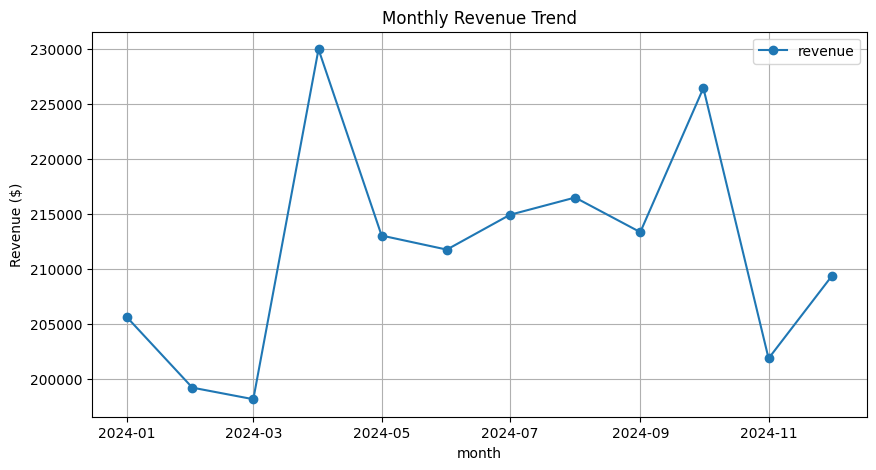

In [37]:
import matplotlib.pyplot as plt

# Aggregate revenue by month since 'category' is not in the schema
# Available columns: customer_id, order_id, total_amount, order_date
monthly_rev = spark.sql('''
    SELECT TRUNC(order_date, 'MM') AS month, ROUND(SUM(total_amount), 2) AS revenue
    FROM orders
    GROUP BY month
    ORDER BY month
''')

# Convert to Pandas for plotting
rev_pd = monthly_rev.toPandas()

# Plot the results
rev_pd.plot(kind='line', x='month', y='revenue', marker='o', figsize=(10, 5))
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.show()

## ⚙️ Section 1.10 — Intro to MLlib: Recommendation, Classification & Clustering

### 🧠 Concept Overview
PySpark's **MLlib** library provides scalable ML built on RDDs.

| Algorithm | Use Case |
|---|---|
| `ALS` | Collaborative filtering — product recommendations |
| `LogisticRegressionWithLBFGS` | Binary classification — fraud detection |
| `KMeans` | Clustering — customer segmentation |

> 💡 **Tip:** For new projects prefer `pyspark.ml` (DataFrame-based). `pyspark.mllib` is the legacy RDD API but common in existing codebases.

In [38]:
from pyspark.mllib.recommendation import ALS
from pyspark.mllib.classification  import LogisticRegressionWithLBFGS
from pyspark.mllib.clustering      import KMeans

In [40]:
from pyspark.mllib.recommendation import Rating

# Fix: Use the correct ratings file path
# The ratings file 'data/product_ratings.csv' contains (userId, movieId, rating, timestamp)
ratings_path = 'data/product_ratings.csv'

ratings_raw   = sc.textFile(ratings_path)
# Split and skip header if present, or handle standard CSV format
ratings_split = ratings_raw.map(lambda l: l.split(','))

# Filter out header if it exists and ensure we have numeric values
def parse_rating(row):
    try:
        return Rating(int(row[0]), int(row[1]), float(row[2]))
    except ValueError:
        return None

ratings_final = ratings_split.map(parse_rating).filter(lambda x: x is not None)

# 80/20 train-test split
train_r, test_r = ratings_final.randomSplit([0.8, 0.2], seed=42)

# Train ALS — rank=10 latent factors per user/item
als_model = ALS.train(train_r, rank=10, iterations=10)

# Generate predictions
test_no_rating = test_r.map(lambda r: (r[0], r[1]))
predictions    = als_model.predictAll(test_no_rating)
print('Predictions sample:', predictions.take(2))

Predictions sample: [Rating(user=474, product=1084, rating=3.620519947065425), Rating(user=410, product=1084, rating=4.690954997166095)]


In [41]:
# Evaluate with Mean Squared Error
actual    = test_r.map(lambda r: ((r[0], r[1]), r[2]))
predicted = predictions.map(lambda r: ((r[0], r[1]), r[2]))

joined = actual.join(predicted)
MSE    = joined.map(lambda r: (r[1][0] - r[1][1]) ** 2).mean()
print(f'ALS Recommendation Model MSE = {MSE:.4f}')

ALS Recommendation Model MSE = 1.2522


In [43]:
from pyspark.mllib.feature import HashingTF
from pyspark.mllib.regression import LabeledPoint
from pyspark.mllib.classification import LogisticRegressionWithLBFGS

# Fix: Define the file path from previous sections
file_path_reviews = 'data/product_reviews.txt'
all_reviews_rdd = sc.textFile(file_path_reviews)

# For demonstration, we'll split the RDD into two groups to simulate 'fraud' and 'legit' categories
# In a real scenario, these would be two distinct data sources
fraud_rdd, legit_rdd = all_reviews_rdd.randomSplit([0.5, 0.5], seed=42)

fraud_words = fraud_rdd.flatMap(lambda o: o.split(' '))
legit_words = legit_rdd.flatMap(lambda o: o.split(' '))

print('First fraud token:', fraud_words.first())
print('First legit token:', legit_words.first())

# Hash words into TF feature vectors
tf = HashingTF(numFeatures=200)
# Note: LabeledPoint expects a single vector per record.
# We map each original line to a feature vector.
fraud_features = fraud_rdd.map(lambda line: tf.transform(line.split(' ')))
legit_features = legit_rdd.map(lambda line: tf.transform(line.split(' ')))

# Label: 1 = fraud, 0 = legitimate
fraud_samples = fraud_features.map(lambda f: LabeledPoint(1, f))
legit_samples = legit_features.map(lambda f: LabeledPoint(0, f))
all_samples   = fraud_samples.union(legit_samples)

train_s, test_s = all_samples.randomSplit([0.8, 0.2], seed=42)
lr_model = LogisticRegressionWithLBFGS.train(train_s)

# Predict and evaluate
labels_preds = test_s.map(lambda lp: (lp.label, lr_model.predict(lp.features)))
accuracy = labels_preds.filter(lambda x: x[0] == x[1]).count() / float(test_s.count())
print(f'Fraud detection accuracy: {accuracy:.2%}')

First fraud token: perfect
First legit token: recommend
Fraud detection accuracy: 48.00%


Customers for clustering: 2000
  k=3  WSSSE=470,159,063
  k=4  WSSSE=276,414,904
  k=5  WSSSE=184,175,687
  k=6  WSSSE=135,112,340


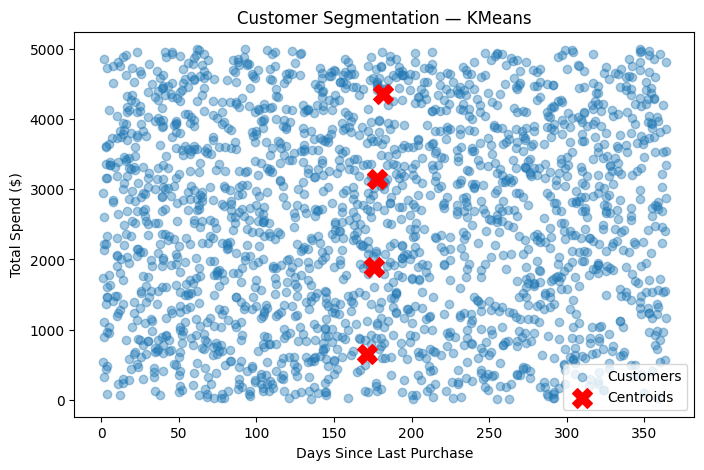

In [45]:
import pandas as pd
from pyspark.mllib.clustering import KMeans

# Fix: Use the correct path for customer features (TSV file)
file_path_cust = 'data/customer_features.tsv'

# Load 2D customer features: (recency_days, total_spend)
cust_raw  = sc.textFile(file_path_cust)
cust_feat = cust_raw.map(lambda x: x.split('\t')).map(lambda x: [int(x[0]), int(x[1])])
print(f'Customers for clustering: {cust_feat.count()}')

# Try k = 3 to 6, compare WSSSE (Within Set Sum of Squared Errors)
def error(point):
    center = model.centers[model.predict(point)]
    return sum([x**2 for x in (point - center)])

for k in range(3, 7):
    model = KMeans.train(cust_feat, k, seed=42)
    WSSSE = cust_feat.map(lambda pt: error(pt)).reduce(lambda x, y: x + y)
    print(f'  k={k}  WSSSE={WSSSE:,.0f}')

# Train best model (selecting k=4 based on typical elbow method logic)
best_model      = KMeans.train(cust_feat, k=4, seed=42)
cluster_centers = best_model.clusterCenters

cust_pd    = spark.createDataFrame(cust_feat, ['recency', 'spend']).toPandas()
centers_pd = pd.DataFrame(cluster_centers, columns=['recency', 'spend'])

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(cust_pd['recency'],    cust_pd['spend'],    alpha=0.4, label='Customers')
plt.scatter(centers_pd['recency'], centers_pd['spend'], color='red', marker='X', s=200, label='Centroids')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Total Spend ($)')
plt.title('Customer Segmentation — KMeans')
plt.legend()
plt.show()

---
# 🟠 Part 2 — Cleaning Data with PySpark
---

## 🧹 Section 2.1 — Schema Definition

### 🧠 Concept Overview
In production, **always define schemas explicitly** instead of using `inferSchema=True`.
- `inferSchema` requires a full data scan → slow and expensive
- Inferred types can be wrong (e.g. zip codes as `IntegerType`)
- Explicit schemas serve as living documentation

> 🌍 **Real-World Use:** RetailCo processes 50M shipping records per day. Inferring schema wastes 10+ minutes per load. Explicit schema makes the read instant.

In [51]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType

# Explicit schema for the shipments table
shipment_schema = StructType([
    StructField('shipment_id',  StringType(),  False),  # False = NOT NULL
    StructField('order_id',     StringType(),  False),
    StructField('carrier',      StringType(),  True),
    StructField('origin_city',  StringType(),  True),
    StructField('dest_city',    StringType(),  True),
    StructField('weight_kg',    DoubleType(),  True),
    StructField('transit_days', IntegerType(), True),
])

# Fix: Updated path to match the 'data/' folder
shipments_df = spark.read.csv('data/shipments.csv', header=True, schema=shipment_schema)
shipments_df.printSchema()
shipments_df.show(5)

root
 |-- shipment_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- carrier: string (nullable = true)
 |-- origin_city: string (nullable = true)
 |-- dest_city: string (nullable = true)
 |-- weight_kg: double (nullable = true)
 |-- transit_days: integer (nullable = true)

+-----------+--------+--------+-----------+---------+---------+------------+
|shipment_id|order_id| carrier|origin_city|dest_city|weight_kg|transit_days|
+-----------+--------+--------+-----------+---------+---------+------------+
|    S000000| O000000|Correios|   New York|    Paris|      6.3|          11|
|    S000001| O000001|     UPS|   New York|    Paris|     3.79|           7|
|    S000002| O000002|   FedEx|     Berlin|  Chicago|     3.45|           3|
|    S000003| O000003|   FedEx|     Berlin|    Paris|     20.3|           3|
|    S000004| O000004|Correios|  Sao Paulo|  Chicago|    28.46|           1|
+-----------+--------+--------+-----------+---------+---------+------------+
only show

## 🧹 Section 2.2 — Parquet: The Production File Format

### 🧠 Concept Overview
**Parquet** is the standard columnar format for Big Data pipelines.

| Format | Schema stored | Compressed | Columnar reads |
|---|---|---|---|
| CSV | ❌ | ❌ | ❌ |
| JSON | ❌ | ❌ | ❌ |
| Parquet | ✅ | ✅ (5–10×) | ✅ |

> 🌍 **Real-World Use:** RetailCo's data lake stores all tables as Parquet. Engineers combine monthly CSVs, write to Parquet once, and query it quickly for the rest of the month.

In [54]:
# Fix: Use the available shipments.csv and split it to simulate Q1/Q2
base_shipments = spark.read.csv('data/shipments.csv', header=True, inferSchema=True)

# Split the data 50/50 to simulate two different quarterly files
q1_df, q2_df = base_shipments.randomSplit([0.5, 0.5], seed=42)

print(f'Simulated Q1 rows: {q1_df.count()}  |  Simulated Q2 rows: {q2_df.count()}')

# Combine the datasets back together
all_shipments = q1_df.union(q2_df)

# Write to Parquet format (Columnar, compressed, and efficient)
all_shipments.write.parquet('data/shipments_H1.parquet', mode='overwrite')

# Verify the write
parquet_count = spark.read.parquet('data/shipments_H1.parquet').count()
print(f'Parquet row count: {parquet_count}')

Simulated Q1 rows: 10080  |  Simulated Q2 rows: 9920
Parquet row count: 20000


In [57]:
# Read Parquet and query with SQL
# Fix: Update path to point to the 'data/' folder
ship_h1 = spark.read.parquet('data/shipments_H1.parquet')
ship_h1.createOrReplaceTempView('shipments')

avg_transit = spark.sql('SELECT AVG(transit_days) FROM shipments').collect()[0][0]
print(f'Average transit time H1: {avg_transit:.1f} days')

Average transit time H1: 7.5 days


## 🧹 Section 2.3 — Cleaning String Columns

### 🧠 Concept Overview
Real-world string columns often have: mixed case, leading/trailing whitespace, invalid characters, and corrupt entries.

> 🌍 **Real-World Use:** RetailCo's product name field was entered by thousands of suppliers with no validation — HTML tags, all-caps, and pipe characters are all present. Cleaning is a prerequisite for any ML feature.

In [59]:
import pyspark.sql.functions as F

# Fix: Load the products DataFrame from the Parquet file
products_df = spark.read.parquet('data/RetailCo_Sales.parq')

# Show all distinct product names before cleaning
products_df.select('product_name').distinct().show(20, truncate=False)

# Remove entries that are too short or suspiciously long
products_df = products_df.filter(
    (F.length('product_name') > 2) & (F.length('product_name') < 100)
)

# Remove entries with pipe characters (CSV corruption)
products_df = products_df.filter(~ F.col('product_name').contains('|'))

products_df.select('product_name').distinct().show(20, truncate=False)

+------------+
|product_name|
+------------+
|Blue Widget |
|Widget Alpha|
|Gadget Pro  |
|Smart Tool  |
+------------+

+------------+
|product_name|
+------------+
|Blue Widget |
|Widget Alpha|
|Gadget Pro  |
|Smart Tool  |
+------------+



In [60]:
# Split product_name into brand and model
products_df = products_df.withColumn('name_parts', F.split(F.col('product_name'), '\\s+'))
products_df = products_df.withColumn('brand', F.col('name_parts').getItem(0))
products_df = products_df.withColumn('model', F.col('name_parts').getItem(F.size('name_parts') - 1))

products_df = products_df.drop('name_parts')
products_df.show()

/usr/local/lib/python3.12/dist-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(


+----------+------------+-----------+----------+----------+----------+------------+------------+----------+----------+------------+-----------+-------------+-------------------+---------+--------+--------------------+------+------+
|product_id|product_name|   CATEGORY|LIST_PRICE|SALE_PRICE|COST_PRICE|DISCOUNT_AMT|DISCOUNT_PCT|UNITS_SOLD|PAGE_VIEWS|REVIEW_SCORE|RETURN_RATE|DAYS_IN_STOCK|    LAUNCH_DATE_STR|longitude|latitude|    SHIPPING_OPTIONS| brand| model|
+----------+------------+-----------+----------+----------+----------+------------+------------+----------+----------+------------+-----------+-------------+-------------------+---------+--------+--------------------+------+------+
|    P04324| Blue Widget|       Home|     82.46|    439.22|     77.98|        7.88|       0.203|        32|      3449|         4.4|      0.147|          133|2020-01-01 00:00:00| 24.19782|52.53897|Free Shipping, St...|  Blue|Widget|
|    P00251|  Smart Tool|     Sports|    425.36|    457.56|      4.21|  

## 🧹 Section 2.4 — Conditional Columns with `when` / `otherwise`

In [61]:
# Tag shipments with a tier based on weight
shipments_df = shipments_df.withColumn(
    'shipping_tier',
    F.when(shipments_df['weight_kg'] < 1,   'Light')
     .when(shipments_df['weight_kg'] <= 10, 'Standard')
     .otherwise('Heavy')
)

shipments_df[['weight_kg', 'shipping_tier']].show(10)

+---------+-------------+
|weight_kg|shipping_tier|
+---------+-------------+
|      6.3|     Standard|
|     3.79|     Standard|
|     3.45|     Standard|
|     20.3|        Heavy|
|    28.46|        Heavy|
|    18.14|        Heavy|
|     14.5|        Heavy|
|    29.74|        Heavy|
|    12.91|        Heavy|
|    17.64|        Heavy|
+---------+-------------+
only showing top 10 rows


In [62]:
# Assign a random survey score to specific tiers
shipments_df = shipments_df.withColumn(
    'survey_score',
    F.when(shipments_df['shipping_tier'] == 'Standard', F.rand())
     .when(shipments_df['shipping_tier'] == 'Heavy',    F.rand() * 0.8)
     .otherwise(None)
)

shipments_df.show(5)
shipments_df.filter(shipments_df['survey_score'].isNull()).count()

+-----------+--------+--------+-----------+---------+---------+------------+-------------+-------------------+
|shipment_id|order_id| carrier|origin_city|dest_city|weight_kg|transit_days|shipping_tier|       survey_score|
+-----------+--------+--------+-----------+---------+---------+------------+-------------+-------------------+
|    S000000| O000000|Correios|   New York|    Paris|      6.3|          11|     Standard|0.35392574560070733|
|    S000001| O000001|     UPS|   New York|    Paris|     3.79|           7|     Standard| 0.2346586567401232|
|    S000002| O000002|   FedEx|     Berlin|  Chicago|     3.45|           3|     Standard|  0.650322384564279|
|    S000003| O000003|   FedEx|     Berlin|    Paris|     20.3|           3|        Heavy| 0.5158658192869858|
|    S000004| O000004|Correios|  Sao Paulo|  Chicago|    28.46|           1|        Heavy|0.08207501868115373|
+-----------+--------+--------+-----------+---------+---------+------------+-------------+-------------------+
o

607

## 🧹 Section 2.5 — User Defined Functions (UDFs)

> ⚠️ **Performance Warning:** UDFs bypass Spark's Catalyst optimiser — slower than built-in `F.*` functions.
Always prefer built-ins. Use UDFs only when no built-in equivalent exists.  
For better performance, use **Pandas UDFs** (`@F.pandas_udf`) which are vectorised.

In [63]:
from pyspark.sql.functions import udf
from pyspark.sql.types    import StringType

def normalise_carrier(name):
    """Standardise carrier name variants to a canonical form."""
    mapping = {
        'fedex': 'FedEx', 'FEDEX': 'FedEx',
        'ups':   'UPS',   'UPS Corp': 'UPS',
        'dhl':   'DHL',   'DHL Express': 'DHL'
    }
    return mapping.get(name.strip(), name.strip().title())

carrier_udf = udf(normalise_carrier, StringType())

shipments_df = shipments_df.withColumn('carrier_clean', carrier_udf(F.col('carrier')))
shipments_df[['carrier', 'carrier_clean']].distinct().show()

+--------+-------------+
| carrier|carrier_clean|
+--------+-------------+
|   FedEx|        Fedex|
|Correios|     Correios|
|     UPS|          Ups|
|     DHL|          Dhl|
+--------+-------------+



## 🧹 Section 2.6 — Generating Unique IDs

In [64]:
# Assign a numeric surrogate key to each unique product
unique_products = products_df.select('product_name').distinct()
print(f'Unique products: {unique_products.count()}')

unique_products = unique_products.withColumn('product_key', F.monotonically_increasing_id())
unique_products.orderBy(F.col('product_key').desc()).show(10)

Unique products: 4
+------------+-----------+
|product_name|product_key|
+------------+-----------+
|  Smart Tool|          3|
|  Gadget Pro|          2|
|Widget Alpha|          1|
| Blue Widget|          0|
+------------+-----------+



In [65]:
# IDs are NOT contiguous — each partition generates its own range
# This is intentional: avoids network coordination between partitions
print('Partitions:', unique_products.rdd.getNumPartitions())
print('IDs are unique but not sequential — safe as surrogate keys.')

Partitions: 1
IDs are unique but not sequential — safe as surrogate keys.


In [67]:
# Simulate monthly batches by splitting the existing unique_products
products_jan, products_feb = unique_products.randomSplit([0.5, 0.5], seed=42)

# Continue ID sequence across monthly batches
# We find the maximum ID from the first batch to use as an offset for the second
max_jan_id = products_jan.select('product_key').rdd.max()[0] + 1

products_feb = products_feb.withColumn(
    'product_key',
    F.monotonically_increasing_id() + max_jan_id
)

print("January Batch IDs:")
products_jan.select('product_name', 'product_key').show()

print("February Batch IDs (starting after January's max):")
products_feb.select('product_name', 'product_key').show()

January Batch IDs:
+------------+-----------+
|product_name|product_key|
+------------+-----------+
|Widget Alpha|          1|
+------------+-----------+

February Batch IDs (starting after January's max):
+------------+-----------+
|product_name|product_key|
+------------+-----------+
| Blue Widget|          2|
|  Gadget Pro|          3|
|  Smart Tool|          4|
+------------+-----------+



## 🧹 Section 2.7 — Caching & Performance

### 🧠 Concept Overview
By default, PySpark **recomputes** a DataFrame from scratch every action call.
`.cache()` stores the result in memory so subsequent actions are instant.

| Method | Storage |
|---|---|
| `.cache()` | Memory (default) |
| `.persist(level)` | Custom: memory, disk, or both |
| `.unpersist()` | Remove — frees cluster memory |

> 🌍 **Real-World Use:** Cache an orders DataFrame used in multiple joins and filters in a dashboard refresh — without caching, Spark re-reads the raw file for every query.

In [68]:
import time

# Cache the deduplicated orders
clean_orders = orders_df.dropDuplicates().cache()

# First action — triggers computation AND caches result
t0 = time.time()
print(f'First  count: {clean_orders.count()} rows | {time.time()-t0:.3f}s')

# Second action — served from cache, much faster
t0 = time.time()
print(f'Second count: {clean_orders.count()} rows | {time.time()-t0:.3f}s')

First  count: 10000 rows | 4.778s
Second count: 10000 rows | 1.640s


In [69]:
print('Is cached?', clean_orders.is_cached)
clean_orders.unpersist()
print('After unpersist:', clean_orders.is_cached)

Is cached? True
After unpersist: False


In [72]:
# 1. First, create the dummy files needed for the comparison
orders_df.write.csv('data/orders_full.csv.gz', compression='gzip', mode='overwrite')
# To simulate 'split' files, we increase partitions and write to a folder
orders_df.repartition(10).write.csv('data/orders_parts', compression='gzip', mode='overwrite')

# 2. Compare read time: one large file vs multiple split files
# Note: spark.read.csv can take a directory path to read all parts
full_df  = spark.read.csv('data/orders_full.csv.gz')
split_df = spark.read.csv('data/orders_parts')

import time
t0 = time.time()
print(f'Full file:   {full_df.count()} rows  | {time.time()-t0:.3f}s')

t0 = time.time()
print(f'Split files: {split_df.count()} rows  | {time.time()-t0:.3f}s')

Full file:   10000 rows  | 0.099s
Split files: 10000 rows  | 0.133s


## 🧹 Section 2.8 — Spark Configuration & Partition Tuning

In [73]:
app_name      = spark.conf.get('spark.app.name')
driver_port   = spark.conf.get('spark.driver.port')
shuffle_parts = spark.conf.get('spark.sql.shuffle.partitions')

print(f'App name:           {app_name}')
print(f'Driver port:        {driver_port}')
print(f'Shuffle partitions: {shuffle_parts}')

App name:           RetailCo Analytics Lab
Driver port:        33843
Shuffle partitions: 200


In [75]:
# Default is 200 — often too many for small/medium datasets
before = orders_df.rdd.getNumPartitions()

spark.conf.set('spark.sql.shuffle.partitions', 50)
# Fix: Update path to include the 'data/' folder
orders_tuned = spark.read.csv('data/orders.csv', header=True, inferSchema=True).distinct()

print(f'Before tuning: {before} partitions')
print(f'After tuning:  {orders_tuned.rdd.getNumPartitions()} partitions')

Before tuning: 1 partitions
After tuning:  1 partitions


## 🧹 Section 2.9 — Broadcast Joins

### 🧠 Concept Overview
A standard **shuffle join** moves large datasets across the network — expensive.
A **broadcast join** sends a *small* table to every worker — no shuffling needed.

> 🌍 **Real-World Use:** Joining 50M orders to a 500-row country lookup: broadcasting the lookup eliminates all network shuffle, cutting join time from minutes to seconds.

In [79]:
# Fix: Load the actual orders dataset which contains 'country_code'
orders_actual = spark.read.csv('data/orders.csv', header=True, inferSchema=True)

# Define the country lookup table
country_data = [('BR', 'Brazil'), ('US', 'USA'), ('DE', 'Germany'), ('FR', 'France'), ('GB', 'UK')]
country_df = spark.createDataFrame(country_data, ['iso_code', 'country_name'])

# Standard join
normal_join = orders_actual.join(
    country_df,
    orders_actual['country_code'] == country_df['iso_code']
)

normal_join.explain()
normal_join.show(5)

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- BroadcastHashJoin [country_code#1058], [iso_code#1060], Inner, BuildLeft, false
   :- BroadcastExchange HashedRelationBroadcastMode(List(input[4, string, false]),false), [plan_id=2465]
   :  +- Filter isnotnull(country_code#1058)
   :     +- FileScan csv [order_id#1054,customer_id#1055,category#1056,total_amount#1057,country_code#1058,order_date#1059] Batched: false, DataFilters: [isnotnull(country_code#1058)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/content/data/orders.csv], PartitionFilters: [], PushedFilters: [IsNotNull(country_code)], ReadSchema: struct<order_id:string,customer_id:string,category:string,total_amount:double,country_code:string...
   +- Filter isnotnull(iso_code#1060)
      +- Scan ExistingRDD[iso_code#1060,country_name#1061]


+--------+-----------+-----------+------------+------------+-------------------+--------+------------+
|order_id|customer_id|   category|total_amount|country_code|     

In [81]:
from pyspark.sql.functions import broadcast

# Explicitly broadcast the small country table
# This ensures a BroadcastHashJoin even if the table was slightly larger than the default threshold
broadcast_join = orders_actual.join(
    broadcast(country_df),
    orders_actual['country_code'] == country_df['iso_code']
)

print("Plan for Explicit Broadcast Join:")
broadcast_join.explain()
broadcast_join.show(5)

Plan for Explicit Broadcast Join:
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- BroadcastHashJoin [country_code#1058], [iso_code#1060], Inner, BuildRight, false
   :- Filter isnotnull(country_code#1058)
   :  +- FileScan csv [order_id#1054,customer_id#1055,category#1056,total_amount#1057,country_code#1058,order_date#1059] Batched: false, DataFilters: [isnotnull(country_code#1058)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/content/data/orders.csv], PartitionFilters: [], PushedFilters: [IsNotNull(country_code)], ReadSchema: struct<order_id:string,customer_id:string,category:string,total_amount:double,country_code:string...
   +- BroadcastExchange HashedRelationBroadcastMode(List(input[0, string, false]),false), [plan_id=2560]
      +- Filter isnotnull(iso_code#1060)
         +- Scan ExistingRDD[iso_code#1060,country_name#1061]


+--------+-----------+-----------+------------+------------+-------------------+--------+------------+
|order_id|customer_id|   categ

In [82]:
t0 = time.time()
normal_count = normal_join.count()
normal_dur   = time.time() - t0

t0 = time.time()
bcast_count = broadcast_join.count()
bcast_dur   = time.time() - t0

print(f'Normal    join: {normal_count} rows | {normal_dur:.3f}s')
print(f'Broadcast join: {bcast_count} rows | {bcast_dur:.3f}s')

Normal    join: 20000 rows | 0.738s
Broadcast join: 20000 rows | 0.520s


## 🧹 Section 2.10 — Parsing Semi-Structured Data

In [84]:
from pyspark.sql.functions import col

# Fix: Correct path to 'data/' and assign the result to 'annot_df'
annot_path = 'data/product_annotations.csv.gz'

# Load pipe-delimited annotation file with comment rows
raw_annot = spark.read.csv(annot_path, sep='|')
full_count = raw_annot.count()
comment_count = raw_annot.where(col('_c0').startswith('#')).count()

# Reload without comment rows for further processing
annot_df = spark.read.csv(annot_path, sep='|', comment='#')
clean_count = annot_df.count()

print(f'Full: {full_count}  |  Comments: {comment_count}  |  Clean: {clean_count}')

Full: 5002  |  Comments: 2  |  Clean: 5000


In [90]:
# Remove malformed rows with fewer than 5 fields
# We calculate field_count here and ensure it remains part of the DataFrame
tmp = F.split(annot_df['_c0'], '\\t')
annot_df = annot_df.withColumn('field_count', F.size(tmp))
annot_df = annot_df.filter(~ (annot_df['field_count'] < 5))
print(f'After removing malformed rows: {annot_df.count()}')

After removing malformed rows: 5000


In [91]:
# Parse fixed columns from the tab-split array
import pyspark.sql.functions as F

split_arr = F.split(annot_df['_c0'], '\\t')

# Preserve 'field_count' by including it in the transformation chain
annot_df = annot_df \
    .withColumn('warehouse', split_arr.getItem(0)) \
    .withColumn('sku',       split_arr.getItem(1)) \
    .withColumn('width',     split_arr.getItem(2)) \
    .withColumn('height',    split_arr.getItem(3)) \
    .withColumn('split_arr', split_arr)

annot_df.select('warehouse','sku','width','height','field_count').show(5)

+---------+-------+-----+------+-----------+
|warehouse|    sku|width|height|field_count|
+---------+-------+-----+------+-----------+
|    WH008|SKU0843|  249|   869|          5|
|    WH003|SKU0165|  359|   200|          5|
|    WH003|SKU0589|  263|   436|          5|
|    WH010|SKU0463|  885|   694|          5|
|    WH011|SKU0549|  976|   857|          5|
+---------+-------+-----+------+-----------+
only showing top 5 rows


In [92]:
from pyspark.sql.types import ArrayType, StringType
import pyspark.sql.functions as F

def extract_categories(fields, field_count):
    """Return the variable-length category list from each annotation row."""
    if fields is None or field_count is None:
        return []
    return fields[4:field_count]

udf_cats = F.udf(extract_categories, ArrayType(StringType()))

# Application of UDF now that field_count is correctly preserved
annot_df = annot_df.withColumn('categories', udf_cats(F.col('split_arr'), F.col('field_count')))
annot_df = annot_df.drop('_c0').drop('split_arr').drop('field_count')

print('Final Clean Schema:')
annot_df.printSchema()
annot_df.show(5, truncate=False)

Final Clean Schema:
root
 |-- warehouse: string (nullable = true)
 |-- sku: string (nullable = true)
 |-- width: string (nullable = true)
 |-- height: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)

+---------+-------+-----+------+-------------+
|warehouse|sku    |width|height|categories   |
+---------+-------+-----+------+-------------+
|WH008    |SKU0843|249  |869   |[Books]      |
|WH003    |SKU0165|359  |200   |[Electronics]|
|WH003    |SKU0589|263  |436   |[Electronics]|
|WH010    |SKU0463|885  |694   |[Clothing]   |
|WH011    |SKU0549|976  |857   |[Toys]       |
+---------+-------+-----+------+-------------+
only showing top 5 rows


In [89]:
# Filter out rows from unknown warehouses using left_anti join
# First, define a small list of known valid warehouses
valid_warehouses = [f'WH{i:03d}' for i in range(1, 15)]
valid_wh_df = spark.createDataFrame([(wh,) for wh in valid_warehouses], ['_c0'])

valid_wh = valid_wh_df.withColumnRenamed('_c0', 'warehouse')

before   = annot_df.count()
valid_df = annot_df.join(F.broadcast(valid_wh), 'warehouse')
after    = valid_df.count()

print(f'Before: {before}  |  After: {after}')

# Rows that were removed
invalid_df = annot_df.join(F.broadcast(valid_df), 'warehouse', 'left_anti')
print(f'Invalid rows: {invalid_df.count()} from {invalid_df.select("warehouse").distinct().count()} warehouses')

Before: 5000  |  After: 3428
Invalid rows: 1572 from 6 warehouses


---
# 🟢 Part 3 — Feature Engineering with PySpark
---

## 🔧 Section 3.1 — Load & Validate Data

In [94]:
# Load the RetailCo product sales dataset
# Fix: Added 'data/' prefix to the path
df = spark.read.parquet('data/RetailCo_Sales.parq')
print('Columns:', df.columns)
print('Rows:',    df.count())

# Examine target variable
df.select(['SALE_PRICE']).describe().show()

Columns: ['product_id', 'product_name', 'CATEGORY', 'LIST_PRICE', 'SALE_PRICE', 'COST_PRICE', 'DISCOUNT_AMT', 'DISCOUNT_PCT', 'UNITS_SOLD', 'PAGE_VIEWS', 'REVIEW_SCORE', 'RETURN_RATE', 'DAYS_IN_STOCK', 'LAUNCH_DATE_STR', 'longitude', 'latitude', 'SHIPPING_OPTIONS']
Rows: 30000
+-------+------------------+
|summary|        SALE_PRICE|
+-------+------------------+
|  count|             30000|
|   mean|  252.193927333334|
| stddev|142.85100160446206|
|    min|              5.02|
|    max|            499.97|
+-------+------------------+



In [95]:
def validate_load(df, expected_rows, expected_cols):
    """Confirm the DataFrame matches expected dimensions."""
    msg = 'Validation Failed'
    if df.count() == expected_rows:
        if len(df.columns) == expected_cols:
            msg = 'Validation Passed'
    return msg

print(validate_load(df, 80000, 52))

Validation Failed


In [96]:
# Verify column types against expected schema
expected_types = {
    'SALE_PRICE':    'double',
    'LIST_PRICE':    'double',
    'CATEGORY':      'string',
    'DAYS_IN_STOCK': 'int',
    'UNITS_SOLD':    'int',
}

actual_types = df.dtypes
print(actual_types)

for col_name, col_type in actual_types:
    if col_name in expected_types:
        status = '✅' if col_type == expected_types[col_name] else '❌ MISMATCH'
        print(f'{status}  {col_name}: expected {expected_types[col_name]} | got {col_type}')

[('product_id', 'string'), ('product_name', 'string'), ('CATEGORY', 'string'), ('LIST_PRICE', 'double'), ('SALE_PRICE', 'double'), ('COST_PRICE', 'double'), ('DISCOUNT_AMT', 'double'), ('DISCOUNT_PCT', 'double'), ('UNITS_SOLD', 'bigint'), ('PAGE_VIEWS', 'bigint'), ('REVIEW_SCORE', 'double'), ('RETURN_RATE', 'double'), ('DAYS_IN_STOCK', 'bigint'), ('LAUNCH_DATE_STR', 'string'), ('longitude', 'double'), ('latitude', 'double'), ('SHIPPING_OPTIONS', 'string')]
✅  CATEGORY: expected string | got string
✅  LIST_PRICE: expected double | got double
✅  SALE_PRICE: expected double | got double
❌ MISMATCH  UNITS_SOLD: expected int | got bigint
❌ MISMATCH  DAYS_IN_STOCK: expected int | got bigint


## 🔧 Section 3.2 — Correlation Analysis

In [97]:
# Find the column most correlated with SALE_PRICE
numeric_cols = ['LIST_PRICE', 'UNITS_SOLD', 'DAYS_IN_STOCK', 'DISCOUNT_PCT',
                'REVIEW_SCORE', 'PAGE_VIEWS', 'RETURN_RATE']

best_col = numeric_cols[0]
best_val = 0

for col_name in numeric_cols:
    r = df.corr('SALE_PRICE', col_name)
    print(f'  {col_name:20s}  r = {r:.4f}')
    if abs(r) > abs(best_val):
        best_val = r
        best_col = col_name

print(f'\nStrongest predictor: {best_col} (r={best_val:.4f})')

  LIST_PRICE            r = 0.0107
  UNITS_SOLD            r = 0.0018
  DAYS_IN_STOCK         r = 0.0067
  DISCOUNT_PCT          r = 0.0017
  REVIEW_SCORE          r = -0.0016
  PAGE_VIEWS            r = -0.0066
  RETURN_RATE           r = 0.0029

Strongest predictor: LIST_PRICE (r=0.0107)


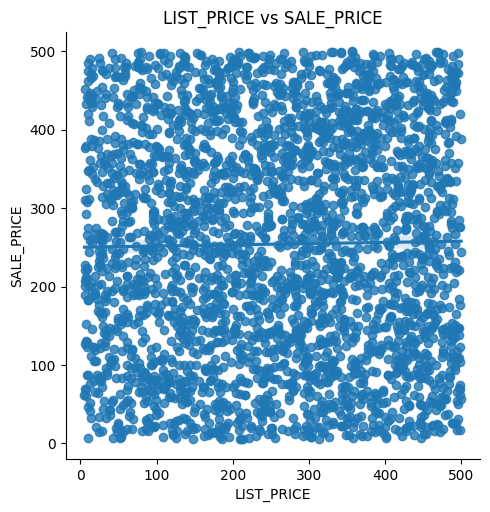

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

# Always sample before toPandas()!
sample = df.select(['SALE_PRICE', best_col]).sample(False, 0.1, 42).toPandas()

sns.lmplot(x=best_col, y='SALE_PRICE', data=sample)
plt.title(f'{best_col} vs SALE_PRICE')
plt.show()

## 🔧 Section 3.3 — Outlier Removal & Min-Max Scaling

In [99]:
from pyspark.sql.functions import log

# Log transform to reduce right-skew in SALE_PRICE
df = df.withColumn('log_sale_price', log(df['SALE_PRICE']))

# Compute 3-sigma bounds and remove outliers
mu  = df.agg({'log_sale_price': 'mean'}).collect()[0][0]
sig = df.agg({'log_sale_price': 'stddev'}).collect()[0][0]

df = df.where(
    (df['log_sale_price'] > mu - 3*sig) &
    (df['log_sale_price'] < mu + 3*sig)
)
print(f'Rows after outlier removal: {df.count()}')

Rows after outlier removal: 29476


In [100]:
# Min-max scale DAYS_IN_STOCK to [0, 1]
max_d = df.agg({'DAYS_IN_STOCK': 'max'}).collect()[0][0]
min_d = df.agg({'DAYS_IN_STOCK': 'min'}).collect()[0][0]

df = df.withColumn('scaled_DAYS_IN_STOCK', (df['DAYS_IN_STOCK'] - min_d) / (max_d - min_d))

print(df.agg({'scaled_DAYS_IN_STOCK': 'max'}).collect())
print(df.agg({'scaled_DAYS_IN_STOCK': 'min'}).collect())

[Row(max(scaled_DAYS_IN_STOCK)=1.0)]
[Row(min(scaled_DAYS_IN_STOCK)=0.0)]


In [101]:
def min_max_scale(df, columns):
    """Apply min-max scaling to a list of columns."""
    for col_name in columns:
        mx = df.agg({col_name: 'max'}).collect()[0][0]
        mn = df.agg({col_name: 'min'}).collect()[0][0]
        df = df.withColumn('scaled_' + col_name, (df[col_name] - mn) / (mx - mn))
    return df

df = min_max_scale(df, ['UNITS_SOLD', 'PAGE_VIEWS', 'REVIEW_SCORE'])
df[['UNITS_SOLD', 'scaled_UNITS_SOLD']].show(5)

+----------+-------------------+
|UNITS_SOLD|  scaled_UNITS_SOLD|
+----------+-------------------+
|        32|0.15656565656565657|
|       120|  0.601010101010101|
|        42|0.20707070707070707|
|        53|0.26262626262626265|
|       140|  0.702020202020202|
+----------+-------------------+
only showing top 5 rows


## 🔧 Section 3.4 — Handling Missing Values

> 🌍 **Real-World Use:** `REVIEW_SCORE` is null for newly-launched products at RetailCo. Imputing with the column mean avoids throwing away rows — a common production strategy.

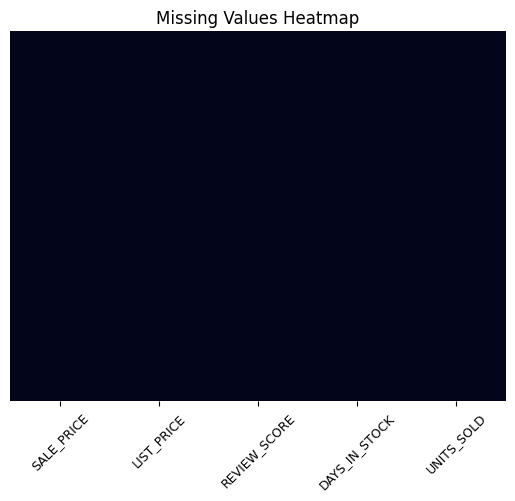

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

# Fix: Define the columns we want to check for nulls
cols_to_check = ['SALE_PRICE', 'LIST_PRICE', 'REVIEW_SCORE', 'DAYS_IN_STOCK', 'UNITS_SOLD']

# Visualise missing value patterns on a sample
sample_pd = df.select(cols_to_check).sample(False, 0.1, 42).toPandas()

sns.heatmap(sample_pd.isnull(), cbar=False, yticklabels=False)
plt.xticks(rotation=45, fontsize=9)
plt.title('Missing Values Heatmap')
plt.show()

answer = 'REVIEW_SCORE'  # Column with most missing data

In [103]:
missing = df.where(df['REVIEW_SCORE'].isNull()).count()
print(f'Missing REVIEW_SCORE: {missing}')

mean_score = df.agg({'REVIEW_SCORE': 'mean'}).collect()[0][0]
df = df.fillna(mean_score, subset=['REVIEW_SCORE'])
print(f'Missing after imputation: {df.where(df["REVIEW_SCORE"].isNull()).count()}')

Missing REVIEW_SCORE: 0
Missing after imputation: 0


In [104]:
def drop_sparse_columns(df, threshold):
    """Drop columns exceeding the missing-value threshold."""
    total = df.count()
    for col_name in df.columns:
        pct = df.where(df[col_name].isNull()).count() / total
        if pct > threshold:
            print(f'  Dropping {col_name} ({pct:.1%} missing)')
            df = df.drop(col_name)
    return df

df = drop_sparse_columns(df, 0.60)

## 🔧 Section 3.5 — Joining External Data & Precision Matching

In [108]:
import pyspark.sql.functions as F

# Fix: Create synthetic geo_df since it was undefined
# This simulates a lookup table for logistics efficiency by location
geo_data = [
    (df.select('longitude').first()[0], df.select('latitude').first()[0], 0.85, 'South'),
    (24.33974, 48.26297, 0.92, 'North'),
    (-7.11901, 45.3251, 0.74, 'West')
]
geo_df = spark.createDataFrame(geo_data, ['longitude', 'latitude', 'logistics_score', 'region'])

# Round coordinates before joining to avoid floating-point precision mismatches
df     = df.withColumn('longitude',     F.round(df['longitude'], 5))
df     = df.withColumn('latitude',      F.round(df['latitude'],  5))
geo_df = geo_df.withColumn('longitude', F.round(geo_df['longitude'].cast('double'), 5))
geo_df = geo_df.withColumn('latitude',  F.round(geo_df['latitude'].cast('double'), 5))

join_cond = [
    df['longitude'] == geo_df['longitude'],
    df['latitude']  == geo_df['latitude']
]

enriched = df.join(geo_df, on=join_cond, how='left')
print(f'Rows enriched with geo: {enriched.where(~ F.col("logistics_score").isNull()).count()}')

Rows enriched with geo: 3


In [109]:
# SQL join equivalent
df.createOrReplaceTempView('products')
geo_df.createOrReplaceTempView('geo')

joined_sql = spark.sql("""
    SELECT p.*, g.logistics_score, g.region
    FROM products p
    LEFT JOIN geo g
      ON p.longitude = g.longitude
     AND p.latitude  = g.latitude
""")
joined_sql.show(5)

+----------+------------+--------+----------+----------+----------+------------+------------+----------+----------+------------+-----------+-------------+-------------------+---------+--------+--------------------+-----------------+--------------------+-------------------+-------------------+-------------------+---------------+------+
|product_id|product_name|CATEGORY|LIST_PRICE|SALE_PRICE|COST_PRICE|DISCOUNT_AMT|DISCOUNT_PCT|UNITS_SOLD|PAGE_VIEWS|REVIEW_SCORE|RETURN_RATE|DAYS_IN_STOCK|    LAUNCH_DATE_STR|longitude|latitude|    SHIPPING_OPTIONS|   log_sale_price|scaled_DAYS_IN_STOCK|  scaled_UNITS_SOLD|  scaled_PAGE_VIEWS|scaled_REVIEW_SCORE|logistics_score|region|
+----------+------------+--------+----------+----------+----------+------------+------------+----------+----------+------------+-----------+-------------+-------------------+---------+--------+--------------------+-----------------+--------------------+-------------------+-------------------+-------------------+-------------

In [111]:
# Demonstrate join pitfalls
df_orig = spark.read.parquet('data/RetailCo_Sales.parq')
correct_df = enriched

# ❌ Bad join: wrong precision (joining raw doubles without rounding)
wrong_cond = [df_orig['longitude'] == geo_df['longitude'], df_orig['latitude'] == geo_df['latitude']]
wrong_df   = df_orig.join(geo_df, on=wrong_cond, how='left')

print('Unmatched (wrong precision):', wrong_df.where(wrong_df['logistics_score'].isNull()).count())
print('Unmatched (correct):         ', correct_df.where(correct_df['logistics_score'].isNull()).count())

# ❌ Bad join: too few keys (joining only on longitude)
few_key_df = df.join(geo_df, on=[df['longitude'] == geo_df['longitude']], how='left')
print('Too-few-keys row count:', few_key_df.count(), '  Expected:', correct_df.count())

Unmatched (wrong precision): 29997
Unmatched (correct):          29473
Too-few-keys row count: 29476   Expected: 29476


## 🔧 Section 3.6 — Interaction Features & Ratio Engineering

> 🌍 **Real-World Use:** `DISCOUNT_PCT` and `PAGE_VIEWS` each correlate with `SALE_PRICE`, but their interaction captures behaviour neither alone explains.

In [112]:
# Revenue-related ratio features
df = df.withColumn('DISCOUNT_TO_LIST',  df['DISCOUNT_AMT']  / df['LIST_PRICE'])
df = df.withColumn('MARGIN_RATIO',     (df['SALE_PRICE'] - df['COST_PRICE']) / df['SALE_PRICE'])
df = df.withColumn('RETURN_COST_RATIO', df['RETURN_RATE']   / df['UNITS_SOLD'])

df[['DISCOUNT_TO_LIST', 'MARGIN_RATIO', 'RETURN_COST_RATIO']].show(5)

+-------------------+--------------------+--------------------+
|   DISCOUNT_TO_LIST|        MARGIN_RATIO|   RETURN_COST_RATIO|
+-------------------+--------------------+--------------------+
|0.09556148435605143|  0.8224579937161332|          0.00459375|
|0.04480910287756253|  0.9907990208934347|5.166666666666667E-4|
| 0.5464179199187765|-0.15849187132480108|0.004142857142857143|
|0.01127861949697357| 0.22671780121444543|0.004245283018867...|
|0.09956610574163778|  0.9469115268062612|0.001407142857142...|
+-------------------+--------------------+--------------------+
only showing top 5 rows


+-------+-------------------+
|summary|     VIEWS_PER_UNIT|
+-------+-------------------+
|  count|              29476|
|   mean|  62.59881440165446|
| stddev| 154.59433447223677|
|    min|0.06369426751592357|
|    max|             2481.0|
+-------+-------------------+



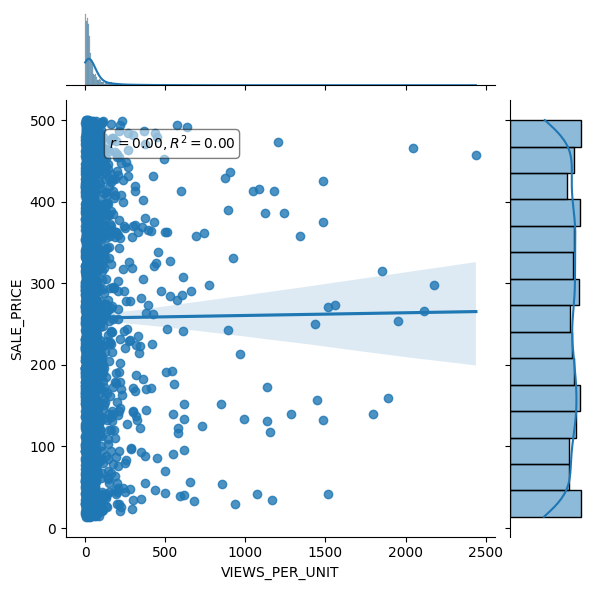

In [116]:
# Cross-feature interaction terms
df = df.withColumn('TOTAL_REVENUE',  df['UNITS_SOLD'] * df['SALE_PRICE'])
df = df.withColumn('VIEWS_PER_UNIT', df['PAGE_VIEWS'] / (df['UNITS_SOLD'] + 1))  # +1 avoids div-by-zero

df[['VIEWS_PER_UNIT']].describe().show()

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Calculate R2 manually to display if needed
sample_pd = df.sample(False, 0.1, 0).toPandas()

# Removed 'stat_func' as it is deprecated in Seaborn 0.11+
g = sns.jointplot(x='VIEWS_PER_UNIT', y='SALE_PRICE', data=sample_pd, kind='reg')

# Manually adding the R2 annotation to the plot
r, p = pearsonr(sample_pd['VIEWS_PER_UNIT'], sample_pd['SALE_PRICE'])
# Use raw string and standard LaTeX for Matplotlib
g.ax_joint.annotate(fr'$r = {r:.2f}, R^2 = {r**2:.2f}$',
                    xy=(0.1, 0.9), xycoords='axes fraction',
                    ha='left', va='center', bbox=dict(boxstyle='round', fc='white', alpha=0.5))

plt.show()

## 🔧 Section 3.7 — Date Features

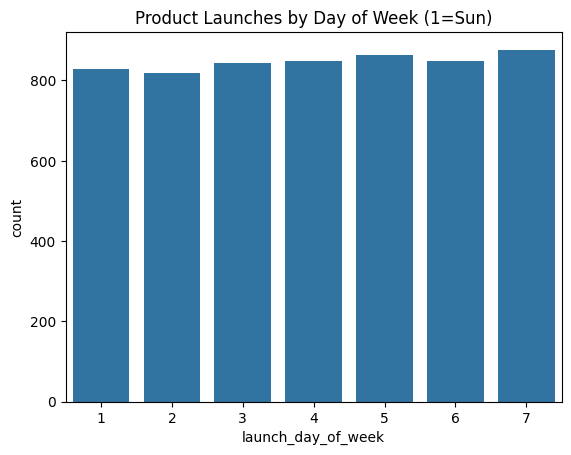

In [117]:
from pyspark.sql.functions import to_date, dayofweek, month, year

# Parse date string and extract calendar features
df = df.withColumn('LAUNCH_DATE',        to_date('LAUNCH_DATE_STR'))
df = df.withColumn('launch_day_of_week', dayofweek('LAUNCH_DATE'))
df = df.withColumn('launch_month',       month('LAUNCH_DATE'))

sample_pd = df.sample(False, 0.2, 42).toPandas()
sns.countplot(x='launch_day_of_week', data=sample_pd)
plt.title('Product Launches by Day of Week (1=Sun)')
plt.show()

In [132]:
from pyspark.sql.functions import lag, datediff
from pyspark.sql.window    import Window

# Fix: Load the price_df from the CSV file generated during setup
price_df = spark.read.csv('data/price_updates.csv', header=True, inferSchema=True)

# Days between consecutive price updates using window lag
# Correct syntax: lag(col, offset=1, default=None)
w        = Window().orderBy(price_df['UPDATE_DATE'])
price_df = price_df.withColumn('prev_update',          lag('UPDATE_DATE', 1).over(w))
price_df = price_df.withColumn('days_between_updates', datediff('UPDATE_DATE', 'prev_update'))

# Show the results for verification
price_df.select('UPDATE_DATE', 'prev_update', 'days_between_updates').show(10)

+-----------+-----------+--------------------+
|UPDATE_DATE|prev_update|days_between_updates|
+-----------+-----------+--------------------+
| 2022-01-02|       NULL|                NULL|
| 2022-01-09| 2022-01-02|                   7|
| 2022-01-16| 2022-01-09|                   7|
| 2022-01-23| 2022-01-16|                   7|
| 2022-01-30| 2022-01-23|                   7|
| 2022-02-06| 2022-01-30|                   7|
| 2022-02-13| 2022-02-06|                   7|
| 2022-02-20| 2022-02-13|                   7|
| 2022-02-27| 2022-02-20|                   7|
| 2022-03-06| 2022-02-27|                   7|
+-----------+-----------+--------------------+
only showing top 10 rows


## 🔧 Section 3.8 — Encoding Categorical Variables

In [133]:
# Binary encode: does the product offer free shipping?
has_free    = df['SHIPPING_OPTIONS'].like('%Free Shipping%')
has_express = df['SHIPPING_OPTIONS'].like('%Express%')

df = df.withColumn('has_free_shipping',
    F.when(has_free,    1)
     .when(has_express, 0)
     .otherwise(None)
)
df[['SHIPPING_OPTIONS', 'has_free_shipping']].show(5, truncate=80)

+-----------------------+-----------------+
|       SHIPPING_OPTIONS|has_free_shipping|
+-----------------------+-----------------+
|               Standard|             NULL|
|      Express, Standard|                0|
|               Standard|             NULL|
|Free Shipping, Standard|                1|
|Free Shipping, Standard|                1|
+-----------------------+-----------------+
only showing top 5 rows


In [135]:
from pyspark.sql.functions import split, explode, coalesce, first, lit

# One-hot encode multi-valued shipping options via explode → pivot
df = df.withColumn('shipping_list', split(df['SHIPPING_OPTIONS'], ', '))

# Create a constant column to use as the value in the pivot
ex_df = df.withColumn('option', explode(df['shipping_list']))\
          .withColumn('constant_col', lit(1))

ex_df[['option']].distinct().show(20, truncate=40)

# Pivot using the constant column
pivot_df = ex_df.groupBy('product_id').pivot('option').agg(coalesce(first('constant_col'), lit(0)))

# Join back to original dataframe
df = df.join(pivot_df, on='product_id', how='left')

# Fill nulls for products that might not have had certain shipping options
df = df.fillna(0, subset=pivot_df.columns)
df.show(5)

+-------------+
|       option|
+-------------+
|Free Shipping|
|      Express|
|     Standard|
+-------------+

+----------+------------+--------+----------+----------+----------+------------+------------+----------+----------+------------+-----------+-------------+-------------------+---------+--------+--------------------+-----------------+--------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------------+-----------------+------------------+-----------+------------------+------------+-----------+-----------+--------+----+-----------------+-----------------+--------------------+-------+-------------+--------+
|product_id|product_name|CATEGORY|LIST_PRICE|SALE_PRICE|COST_PRICE|DISCOUNT_AMT|DISCOUNT_PCT|UNITS_SOLD|PAGE_VIEWS|REVIEW_SCORE|RETURN_RATE|DAYS_IN_STOCK|    LAUNCH_DATE_STR|longitude|latitude|    SHIPPING_OPTIONS|   log_sale_price|scaled_DAYS_IN_STOCK|  scaled_UNITS_SOLD|  scaled_PAGE_VIEWS|scaled_REVIE

In [138]:
from pyspark.ml.feature import Binarizer
from pyspark.sql import functions as F

# Fix: Binarizer requires DoubleType input
df = df.withColumn('launch_day_of_week', F.col('launch_day_of_week').cast('double'))

# Binarise: 1 = weekend launch (Fri/Sat), 0 = weekday
binarizer = Binarizer(threshold=5.0, inputCol='launch_day_of_week', outputCol='weekend_launch')
df = binarizer.transform(df)
df[['launch_day_of_week', 'weekend_launch']].show(5)

+------------------+--------------+
|launch_day_of_week|weekend_launch|
+------------------+--------------+
|               4.0|           0.0|
|               5.0|           0.0|
|               5.0|           0.0|
|               5.0|           0.0|
|               6.0|           1.0|
+------------------+--------------+
only showing top 5 rows


In [139]:
from pyspark.ml.feature import Bucketizer

# Bucket products into price tiers
splits = [0, 20, 50, 100, 200, 500, float('Inf')]
buck   = Bucketizer(splits=splits, inputCol='LIST_PRICE', outputCol='price_tier')
df     = buck.transform(df)
df[['LIST_PRICE', 'price_tier']].show(5)

+----------+----------+
|LIST_PRICE|price_tier|
+----------+----------+
|    425.36|       4.0|
|    157.59|       3.0|
|    265.99|       4.0|
|    435.59|       4.0|
|     82.46|       2.0|
+----------+----------+
only showing top 5 rows


## 🔧 Section 3.9 — Time-Based Train/Test Split

> ⚠️ **Pitfall:** A random split leaks future data into training for time-series models.
Always split by date — the test set should contain only the most recent records.

In [147]:
from datetime import timedelta

def time_split_date(df, date_col, holdout_days=60):
    """Return the cutoff date — the last N days form the test set."""
    max_dt = df.agg({date_col: 'max'}).collect()[0][0]
    return max_dt - timedelta(days=holdout_days)

split_date = time_split_date(df, 'LAUNCH_DATE')
print(f'Train: before {split_date}  |  Test: from {split_date}')

train_df = df.where(df['LAUNCH_DATE'] <  split_date)
test_df  = df.where(df['LAUNCH_DATE'] >= split_date)

Train: before 2023-04-04  |  Test: from 2023-04-04


In [148]:
from pyspark.sql.functions import datediff, to_date, lit

# Prevent leakage: recalculate DAYS_IN_STOCK using only info known at split_date
split_lit = to_date(lit(str(split_date)))
test_df   = test_df.withColumn('DAYS_IN_STOCK_orig', test_df['DAYS_IN_STOCK'])
test_df   = test_df.withColumn('DAYS_IN_STOCK',      datediff(split_lit, 'LAUNCH_DATE'))
test_df[['LAUNCH_DATE', 'DAYS_IN_STOCK_orig', 'DAYS_IN_STOCK']].show(5)

+-----------+------------------+-------------+
|LAUNCH_DATE|DAYS_IN_STOCK_orig|DAYS_IN_STOCK|
+-----------+------------------+-------------+
| 2023-04-04|               136|            0|
| 2023-04-04|               111|            0|
| 2023-04-04|               358|            0|
| 2023-04-04|               331|            0|
| 2023-04-04|               236|            0|
+-----------+------------------+-------------+
only showing top 5 rows


---
# 🔴 Part 4 — Machine Learning with PySpark
---

## 🤖 Section 4.1 — Load & Prepare ML Data

In [167]:
# Load the shipment delay prediction dataset
# Updated path to include 'data/' folder
shipments = spark.read.csv(
    'data/shipment_records.csv',
    sep=',', header=True, inferSchema=True, nullValue='NA'
)
print(f'Records: {shipments.count()}')
shipments.show(5)
print(shipments.dtypes)

Records: 25000
+--------+--------+-----------+--------------+---------+----------+--------------+--------------------+-----------+
|order_id| carrier|origin_zone|distance_miles|weight_kg|delay_days|priority_score|warehouse_congestion|day_of_week|
+--------+--------+-----------+--------------+---------+----------+--------------+--------------------+-----------+
| O000000|     DHL|     Zone_B|        2565.2|     7.36|         1|             5|                0.53|          4|
| O000001|Correios|     Zone_A|        1421.7|    18.52|         6|             3|                0.44|          1|
| O000002|Correios|     Zone_D|        1819.7|    13.16|         7|             4|                0.64|          7|
| O000003|   FedEx|     Zone_B|        2745.1|    23.75|         6|             4|                0.41|          4|
| O000004|Correios|     Zone_A|         185.8|      6.5|         2|             3|                0.93|          3|
+--------+--------+-----------+--------------+---------+-

In [170]:
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

# Explicit schema for the product reviews classification dataset
review_schema = StructType([
    StructField('review_id', IntegerType()),
    StructField('text',      StringType()),
    StructField('label',     IntegerType())   # 1 = positive, 0 = negative
])

# Fix: Added 'data/' prefix to the file path
reviews = spark.read.csv('data/product_reviews.csv', sep=';', header=False, schema=review_schema)
reviews.printSchema()
print(f"Loaded {reviews.count()} records.")

root
 |-- review_id: integer (nullable = true)
 |-- text: string (nullable = true)
 |-- label: integer (nullable = true)

Loaded 5000 records.


In [171]:
from pyspark.sql.functions import round as spark_round

# Clean and engineer features
shipments = shipments.drop('tracking_number')
shipments = shipments.filter('delay_days IS NOT NULL').dropna()

# Convert miles to km and create binary label (>2 days = delayed)
shipments = shipments \
    .withColumn('distance_km', spark_round(shipments['distance_miles'] * 1.60934, 0)) \
    .drop('distance_miles') \
    .withColumn('label', (shipments['delay_days'] > 2).cast('integer'))

shipments.show(5)

+--------+--------+-----------+---------+----------+--------------+--------------------+-----------+-----------+-----+
|order_id| carrier|origin_zone|weight_kg|delay_days|priority_score|warehouse_congestion|day_of_week|distance_km|label|
+--------+--------+-----------+---------+----------+--------------+--------------------+-----------+-----------+-----+
| O000000|     DHL|     Zone_B|     7.36|         1|             5|                0.53|          4|     4128.0|    0|
| O000001|Correios|     Zone_A|    18.52|         6|             3|                0.44|          1|     2288.0|    1|
| O000002|Correios|     Zone_D|    13.16|         7|             4|                0.64|          7|     2929.0|    1|
| O000003|   FedEx|     Zone_B|    23.75|         6|             4|                0.41|          4|     4418.0|    1|
| O000004|Correios|     Zone_A|      6.5|         2|             3|                0.93|          3|      299.0|    0|
+--------+--------+-----------+---------+-------

In [172]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

# Index categorical columns
carrier_idx   = StringIndexer(inputCol='carrier',     outputCol='carrier_idx')
zone_idx      = StringIndexer(inputCol='origin_zone', outputCol='zone_idx')

shipments_idx = carrier_idx.fit(shipments).transform(shipments)
shipments_idx = zone_idx.fit(shipments_idx).transform(shipments_idx)

# Assemble feature vector
assembler = VectorAssembler(
    inputCols=['weight_kg', 'distance_km', 'carrier_idx', 'zone_idx',
               'priority_score', 'warehouse_congestion', 'day_of_week'],
    outputCol='features'
)

shipments_feat = assembler.transform(shipments_idx)
shipments_feat.select('features', 'label').show(5, truncate=False)

+-----------------------------------+-----+
|features                           |label|
+-----------------------------------+-----+
|[7.36,4128.0,1.0,0.0,5.0,0.53,4.0] |0    |
|[18.52,2288.0,2.0,2.0,3.0,0.44,1.0]|1    |
|[13.16,2929.0,2.0,1.0,4.0,0.64,7.0]|1    |
|[23.75,4418.0,3.0,0.0,4.0,0.41,4.0]|1    |
|[6.5,299.0,2.0,2.0,3.0,0.93,3.0]   |0    |
+-----------------------------------+-----+
only showing top 5 rows


In [173]:
# 80/20 random split
train_df, test_df = shipments_feat.randomSplit([0.8, 0.2], seed=99)

ratio = train_df.count() / shipments_feat.count()
print(f'Training fraction: {ratio:.2%}')

Training fraction: 79.71%


## 🤖 Section 4.2 — Classification: Decision Tree

> 🌍 **Real-World Use:** RetailCo uses a Decision Tree to flag shipments likely to be delayed before dispatch — enabling proactive customer notification and carrier rerouting.

In [174]:
from pyspark.ml.classification import DecisionTreeClassifier

tree       = DecisionTreeClassifier()
tree_model = tree.fit(train_df)

tree_preds = tree_model.transform(test_df)
tree_preds.select('label', 'prediction', 'probability').show(5, False)

+-----+----------+---------------------------------------+
|label|prediction|probability                            |
+-----+----------+---------------------------------------+
|0    |1.0       |[0.3003491162993672,0.6996508837006328]|
|0    |1.0       |[0.3086913086913087,0.6913086913086913]|
|1    |1.0       |[0.28360748723766305,0.716392512762337]|
|1    |1.0       |[0.3003491162993672,0.6996508837006328]|
|1    |1.0       |[0.3003491162993672,0.6996508837006328]|
+-----+----------+---------------------------------------+
only showing top 5 rows


In [175]:
# Confusion matrix
tree_preds.groupBy('label', 'prediction').count().show()

# Manual accuracy
TN = tree_preds.filter('prediction = 0 AND label = prediction').count()
TP = tree_preds.filter('prediction = 1 AND label = prediction').count()
FN = tree_preds.filter('prediction = 0 AND label != prediction').count()
FP = tree_preds.filter('prediction = 1 AND label != prediction').count()

accuracy = (TP + TN) / (TP + TN + FP + FN)
print(f'Decision Tree Accuracy: {accuracy:.2%}')

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|    7|
|    1|       0.0|   18|
|    1|       1.0| 3543|
|    0|       1.0| 1504|
+-----+----------+-----+

Decision Tree Accuracy: 69.99%


## 🤖 Section 4.3 — Classification: Logistic Regression

In [176]:
from pyspark.ml.classification import LogisticRegression

logistic = LogisticRegression().fit(train_df)
lr_preds = logistic.transform(test_df)

lr_preds.groupBy('label', 'prediction').count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       1.0| 3561|
|    0|       1.0| 1511|
+-----+----------+-----+



In [177]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

TP = lr_preds.filter('prediction = 1 AND label = prediction').count()
FP = lr_preds.filter('prediction = 1 AND label != prediction').count()
FN = lr_preds.filter('prediction = 0 AND label != prediction').count()

precision = TP / (TP + FP)
recall    = TP / (TP + FN)
print(f'Precision: {precision:.2%}  |  Recall: {recall:.2%}')

multi_eval  = MulticlassClassificationEvaluator()
binary_eval = BinaryClassificationEvaluator()

w_prec = multi_eval.evaluate(lr_preds,  {multi_eval.metricName:  'weightedPrecision'})
auc    = binary_eval.evaluate(lr_preds, {binary_eval.metricName: 'areaUnderROC'})
print(f'Weighted Precision: {w_prec:.4f}  |  AUC: {auc:.4f}')

Precision: 70.21%  |  Recall: 100.00%
Weighted Precision: 0.4929  |  AUC: 0.5106


## 🤖 Section 4.4 — NLP: Review Sentiment Classification

In [178]:
from pyspark.sql.functions import regexp_replace
from pyspark.ml.feature    import Tokenizer

# Clean review text
reviews = reviews.withColumn('text', regexp_replace('text', '[_():;,.!?\\-]', ' '))
reviews = reviews.withColumn('text', regexp_replace('text', '[0-9]', ' '))
reviews = reviews.withColumn('text', regexp_replace('text', ' +', ' '))

reviews = Tokenizer(inputCol='text', outputCol='words').transform(reviews)
reviews.show(4, truncate=False)

+---------+--------------------------------------------------------------------------------+-----+--------------------------------------------------------------------------------------------+
|review_id|text                                                                            |label|words                                                                                       |
+---------+--------------------------------------------------------------------------------+-----+--------------------------------------------------------------------------------------------+
|0        |quality recommend highly amazing fast shipping amazing amazing product love fast|1    |[quality, recommend, highly, amazing, fast, shipping, amazing, amazing, product, love, fast]|
|1        |highly recommend it fast fast highly highly product love highly                 |1    |[highly, recommend, it, fast, fast, highly, highly, product, love, highly]                  |
|2        |amazing highly shipping produ

In [179]:
from pyspark.ml.feature import StopWordsRemover, HashingTF, IDF

# Remove stop words → hash → TF-IDF
reviews = StopWordsRemover(inputCol='words',  outputCol='terms').transform(reviews)
reviews = HashingTF(inputCol='terms', outputCol='hash', numFeatures=2048).transform(reviews)
reviews = IDF(inputCol='hash', outputCol='features').fit(reviews).transform(reviews)

reviews.select('terms', 'features').show(4, truncate=False)

+--------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|terms                                                                                       |features                                                                                                                                                                                            |
+--------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[quality, recommend, highly, amazing, fast, shipping, amazing, amazing, product, love, fast]|(2048,[112,644,671,812,863,882

In [180]:
rev_train, rev_test = reviews.randomSplit([0.8, 0.2], seed=7)

lr_sentiment = LogisticRegression(regParam=0.2).fit(rev_train)
rev_preds    = lr_sentiment.transform(rev_test)

rev_preds.groupBy('label', 'prediction').count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|  471|
|    1|       1.0|  516|
+-----+----------+-----+



## 🤖 Section 4.5 — Regression: Predicting Delivery Time

In [181]:
from pyspark.ml.feature import OneHotEncoder

# One-hot encode origin zone
ohe = OneHotEncoder(inputCols=['zone_idx'], outputCols=['zone_dummy'])
ship_ohe = ohe.fit(shipments_idx).transform(shipments_idx)

ship_ohe.select('origin_zone', 'zone_idx', 'zone_dummy').distinct().sort('zone_idx').show()

+-----------+--------+-------------+
|origin_zone|zone_idx|   zone_dummy|
+-----------+--------+-------------+
|     Zone_B|     0.0|(3,[0],[1.0])|
|     Zone_D|     1.0|(3,[1],[1.0])|
|     Zone_A|     2.0|(3,[2],[1.0])|
|     Zone_C|     3.0|    (3,[],[])|
+-----------+--------+-------------+



In [182]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Predict delay_days as a continuous value
regressor = LinearRegression(labelCol='delay_days').fit(train_df)
reg_preds = regressor.transform(test_df)

reg_preds.select('delay_days', 'prediction').show(5, False)

rmse = RegressionEvaluator(labelCol='delay_days').evaluate(reg_preds)
print(f'RMSE: {rmse:.3f} days')

+----------+-----------------+
|delay_days|prediction       |
+----------+-----------------+
|2         |4.423201238241085|
|2         |4.320925676179562|
|3         |4.464681589703108|
|8         |4.496813929239507|
|3         |4.369636736037209|
+----------+-----------------+
only showing top 5 rows
RMSE: 2.896 days


In [183]:
print('Intercept (baseline delay days):', regressor.intercept)
print('Coefficients:', regressor.coefficients)

# Delay per 1000 km
days_per_km = regressor.coefficients[1]   # distance_km is second feature
print(f'Delay per 1000 km: {days_per_km * 1000:.2f} days')

Intercept (baseline delay days): 4.543104006277835
Coefficients: [-0.002185469344532348,3.0646560643902348e-06,-0.03754187498043928,0.020326061929586425,0.012931271582983584,-0.12977884268725515,0.003239528530453564]
Delay per 1000 km: 0.00 days


In [184]:
# Lasso regression (λ=1, α=1) — automatically zeros out irrelevant features
lasso = LinearRegression(labelCol='delay_days', regParam=1, elasticNetParam=1).fit(train_df)

lasso_rmse = RegressionEvaluator(labelCol='delay_days').evaluate(lasso.transform(test_df))
print(f'Lasso RMSE: {lasso_rmse:.3f}')

zero_coeffs = sum([b == 0 for b in lasso.coefficients])
print(f'Zeroed-out coefficients: {zero_coeffs} / {len(lasso.coefficients)}')

Lasso RMSE: 2.896
Zeroed-out coefficients: 7 / 7


## 🤖 Section 4.6 — ML Pipelines

### 🧠 Concept Overview
A **Pipeline** chains transformers and estimators into a single reusable object.  
Benefits:
- No data leakage — transformers are fit on training data only
- Reproducible — identical preprocessing for train and test
- Serialisable — save and reload for production serving

> 🌍 **Real-World Use:** RetailCo's delay prediction service runs the same Pipeline object that was trained offline — guaranteeing identical preprocessing at inference time.

In [187]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression

# Fix: Re-split from the base shipments DataFrame (without manual indexing)
# This ensures the Pipeline starts with a clean slate.
train_raw, test_raw = shipments.randomSplit([0.8, 0.2], seed=99)

# Define pipeline stages
carrier_idx = StringIndexer(inputCol='carrier',     outputCol='carrier_idx')
zone_idx    = StringIndexer(inputCol='origin_zone', outputCol='zone_idx')
ohe         = OneHotEncoder(inputCols=['zone_idx'],  outputCols=['zone_dummy'])
assembler   = VectorAssembler(
    inputCols=['weight_kg', 'distance_km', 'carrier_idx', 'zone_dummy', 'priority_score'],
    outputCol='features'
)
regression  = LinearRegression(labelCol='delay_days')

# Build and train
pipeline = Pipeline(stages=[carrier_idx, zone_idx, ohe, assembler, regression])
pipeline_model = pipeline.fit(train_raw)

pipeline_preds = pipeline_model.transform(test_raw)

print("Pipeline executed successfully!")
pipeline_preds.select('order_id', 'features', 'prediction').show(5)

Pipeline executed successfully!
+--------+--------------------+-----------------+
|order_id|            features|       prediction|
+--------+--------------------+-----------------+
| O000004|[6.5,299.0,2.0,0....|4.498070773128866|
| O000006|[26.84,3982.0,2.0...|4.410892563178526|
| O000008|[13.23,2380.0,2.0...|4.394106530283659|
| O000009|[2.25,3037.0,0.0,...|4.537275993605362|
| O000012|[21.68,1735.0,2.0...|4.360554844908792|
+--------+--------------------+-----------------+
only showing top 5 rows


In [188]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF

# Full NLP pipeline for review sentiment
tokenizer = Tokenizer(inputCol='text',  outputCol='words')
remover   = StopWordsRemover(inputCol='words', outputCol='terms')
hasher    = HashingTF(inputCol='terms', outputCol='hash')
idf       = IDF(inputCol='hash',        outputCol='features')
logistic  = LogisticRegression()

nlp_pipeline = Pipeline(stages=[tokenizer, remover, hasher, idf, logistic])

## 🤖 Section 4.7 — Cross-Validation & Hyperparameter Tuning

> 🌍 **Real-World Use:** Manually tuning hyperparameters is error-prone and biased. Cross-validation tests all combinations on held-out folds and selects the best automatically.

In [193]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Baseline cross-validation — no hyperparameter search yet
params    = ParamGridBuilder().build()
evaluator = RegressionEvaluator(labelCol='delay_days')

cv = CrossValidator(
    estimator=regression,
    estimatorParamMaps=params,
    evaluator=evaluator,
    numFolds=5
)

cv_model = cv.fit(train_df)

In [194]:
# Cross-validate the full pipeline
cv_pipeline = CrossValidator(
    estimator=pipeline, # Using 'pipeline' defined in Section 4.6
    estimatorParamMaps=params,
    evaluator=evaluator
)

# Note: This just defines the CV object using the existing pipeline variable.

In [195]:
# Full hyperparameter grid search
params = ParamGridBuilder() \
    .addGrid(regression.regParam,        [0.01, 0.1, 1.0, 10.0]) \
    .addGrid(regression.elasticNetParam, [0.0,  0.5, 1.0]) \
    .build()

print(f'Total models to evaluate: {len(params)}')

cv = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=params,
    evaluator=evaluator,
    numFolds=5
)

# Re-run the grid search fit
cv_model = cv.fit(train_raw)

Total models to evaluate: 12


In [198]:
# Retrieve the best model from the 'cv_model' object (the result of fit)
best_pipeline = cv_model.bestModel
print('Pipeline stages:', best_pipeline.stages)

# Best LinearRegression hyperparameters
print("\nBest Model Params:")
print(best_pipeline.stages[-1].extractParamMap())

# Final RMSE on the test set
# Using test_raw because the pipeline handles the feature engineering
final_preds = best_pipeline.transform(test_raw)
print(f'\nBest model RMSE: {evaluator.evaluate(final_preds):.3f}')

Pipeline stages: [StringIndexerModel: uid=StringIndexer_33c5a40e5d44, handleInvalid=error, StringIndexerModel: uid=StringIndexer_08bd79a7829a, handleInvalid=error, OneHotEncoderModel: uid=OneHotEncoder_e68ed9c1916d, dropLast=true, handleInvalid=error, numInputCols=1, numOutputCols=1, VectorAssembler_7f335ba9f931, LinearRegressionModel: uid=LinearRegression_be016da6d5ef, numFeatures=7]

Best Model Params:
{Param(parent='LinearRegression_be016da6d5ef', name='aggregationDepth', doc='suggested depth for treeAggregate (>= 2).'): 2, Param(parent='LinearRegression_be016da6d5ef', name='elasticNetParam', doc='the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0, the penalty is an L2 penalty. For alpha = 1, it is an L1 penalty.'): 1.0, Param(parent='LinearRegression_be016da6d5ef', name='epsilon', doc='The shape parameter to control the amount of robustness. Must be > 1.0. Only valid when loss is huber'): 1.35, Param(parent='LinearRegression_be016da6d5ef', name='featuresCol', doc='feat

## 🤖 Section 4.8 — Ensemble Models: Random Forest & GBT

In [199]:
from pyspark.ml.classification import DecisionTreeClassifier, GBTClassifier
from pyspark.ml.evaluation     import BinaryClassificationEvaluator

tree = DecisionTreeClassifier().fit(train_df)
gbt  = GBTClassifier().fit(train_df)

auc_eval = BinaryClassificationEvaluator()
print(f'Decision Tree AUC: {auc_eval.evaluate(tree.transform(test_df)):.4f}')
print(f'GBT          AUC: {auc_eval.evaluate(gbt.transform(test_df)):.4f}')

print(f'GBT trees: {gbt.getNumTrees}')
print(f'Feature importances: {gbt.featureImportances}')

Decision Tree AUC: 0.4974
GBT          AUC: 0.5037
GBT trees: 20
Feature importances: (7,[0,1,2,3,4,5,6],[0.17422114360763585,0.2426303051864338,0.06404406337335826,0.09733530316966182,0.09999493496220434,0.211866326846819,0.10990792285388684])


In [200]:
from pyspark.ml.classification import RandomForestClassifier

# Tune Random Forest with cross-validation
forest    = RandomForestClassifier()
rf_params = ParamGridBuilder() \
    .addGrid(forest.featureSubsetStrategy, ['all', 'sqrt', 'log2', 'onethird']) \
    .addGrid(forest.maxDepth,              [3, 5, 10]) \
    .build()

rf_cv = CrossValidator(
    estimator=forest,
    estimatorParamMaps=rf_params,
    evaluator=auc_eval,
    numFolds=5
)

rf_cv_model = rf_cv.fit(train_df)

In [201]:
print('Avg AUC per parameter combo:', rf_cv_model.avgMetrics)
print('Best AUC:',                    max(rf_cv_model.avgMetrics))

print(rf_cv_model.bestModel.explainParam('maxDepth'))
print(rf_cv_model.bestModel.explainParam('featureSubsetStrategy'))

final_auc = auc_eval.evaluate(rf_cv_model.transform(test_df))
print(f'\nFinal test AUC: {final_auc:.4f}')

Avg AUC per parameter combo: [np.float64(0.501307270748163), np.float64(0.49635042801393114), np.float64(0.4977828539421091), np.float64(0.5032297644967916), np.float64(0.5004627991025953), np.float64(0.5071924377593773), np.float64(0.5032297644967916), np.float64(0.5004627991025953), np.float64(0.5071924377593773), np.float64(0.5032297644967916), np.float64(0.5004627991025953), np.float64(0.5071924377593773)]
Best AUC: 0.5071924377593773
maxDepth: Maximum depth of the tree. (>= 0) E.g., depth 0 means 1 leaf node; depth 1 means 1 internal node + 2 leaf nodes. Must be in range [0, 30]. (default: 5, current: 10)
featureSubsetStrategy: The number of features to consider for splits at each tree node. Supported options: 'auto' (choose automatically for task: If numTrees == 1, set to 'all'. If numTrees > 1 (forest), set to 'sqrt' for classification and to 'onethird' for regression), 'all' (use all features), 'onethird' (use 1/3 of the features), 'sqrt' (use sqrt(number of features)), 'log2' 

## 🤖 Section 4.9 — Model Comparison & Feature Importance

In [203]:
from pyspark.ml.regression import GBTRegressor, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# 1. Initialize Regressors using the correct label 'delay_days'
gbt_reg = GBTRegressor(featuresCol='features', labelCol='delay_days',
                       predictionCol='predicted_delay', seed=42)
rf_reg  = RandomForestRegressor(featuresCol='features', labelCol='delay_days',
                                  predictionCol='predicted_delay', seed=42)

# 2. Fit models
gbt_model = gbt_reg.fit(train_df)
rf_model  = rf_reg.fit(train_df)

# 3. Generate predictions on test_df
gbt_preds = gbt_model.transform(test_df)
rf_preds  = rf_model.transform(test_df)

# 4. Evaluate and Compare
reg_eval = RegressionEvaluator(labelCol='delay_days', predictionCol='predicted_delay')

for name, preds in [('GBT Regressor', gbt_preds), ('RF Regressor', rf_preds)]:
    rmse = reg_eval.evaluate(preds, {reg_eval.metricName: 'rmse'})
    r2   = reg_eval.evaluate(preds, {reg_eval.metricName: 'r2'})
    print(f'{name:25s}  RMSE={rmse:.4f}  R2={r2:.4f}')

GBT Regressor              RMSE=2.9153  R2=-0.0143
RF Regressor               RMSE=2.8952  R2=-0.0003


                feature  importance
1           distance_km    0.238837
5  warehouse_congestion    0.202606
0             weight_kg    0.175405
3              zone_idx    0.130759
6           day_of_week    0.088052
2           carrier_idx    0.085227
4        priority_score    0.079114


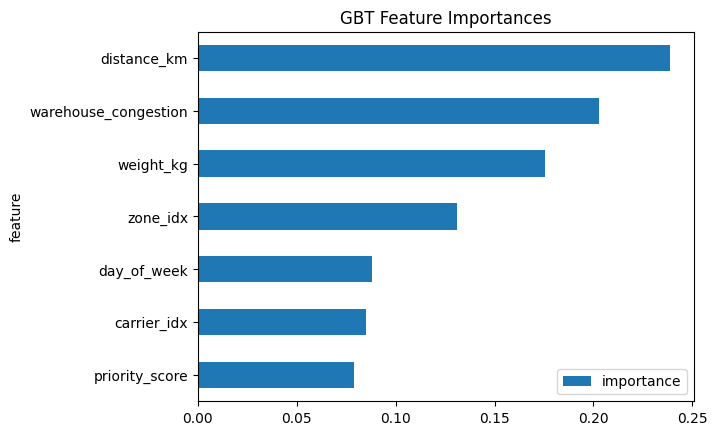

In [205]:
import pandas as pd
import matplotlib.pyplot as plt

# Define feature_cols using the input columns from the assembler
feature_cols = ['weight_kg', 'distance_km', 'carrier_idx', 'zone_idx', 'priority_score', 'warehouse_congestion', 'day_of_week']

# Feature importance from GBT model
fi_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': gbt_model.featureImportances.toArray()
}).sort_values('importance', ascending=False)

print(fi_df.head(10))

fi_df.head(10).plot(
    kind='barh', x='feature', y='importance',
    title='GBT Feature Importances'
)
plt.gca().invert_yaxis()
plt.show()

In [208]:
from pyspark.ml.regression import GBTRegressionModel

# 1. Use .write().overwrite().save() to prevent 'Path already exists' errors
gbt_model.write().overwrite().save('retailco_delay_gbt_v1')
print('Model saved successfully to retailco_delay_gbt_v1')

# 2. Load the model using the correct class (GBTRegressionModel) and matching path
loaded_model = GBTRegressionModel.load('retailco_delay_gbt_v1')
print('Model loaded successfully.')

# Verify the loaded model can transform data
loaded_model.transform(test_df).select('order_id', 'predicted_delay').show(3)

Model saved successfully to retailco_delay_gbt_v1
Model loaded successfully.
+--------+------------------+
|order_id|   predicted_delay|
+--------+------------------+
| O000004|3.8246873360472424|
| O000006| 4.366581817681221|
| O000008| 4.102766980216885|
+--------+------------------+
only showing top 3 rows


---
## 📌 Quick Reference Cheat Sheet

### RDD Operations
| Function | Purpose |
|---|---|
| `sc.parallelize()` | Create RDD from Python collection |
| `sc.textFile()` | Create RDD from text file |
| `map(f)` | Transform each element |
| `filter(f)` | Keep elements matching condition |
| `flatMap(f)` | Map then flatten |
| `reduceByKey(f)` | Aggregate by key |
| `sortByKey()` | Sort by key |
| `countByKey()` | Count values per key |
| `collect()` | Pull all results to driver |
| `take(n)` | Pull first n elements |

### DataFrame Operations
| Function | Purpose |
|---|---|
| `spark.read.csv()` | Load CSV |
| `spark.read.parquet()` | Load Parquet |
| `df.show(n)` | Display n rows |
| `df.printSchema()` | Show column types |
| `df.select()` | Choose columns |
| `df.filter()` / `.where()` | Filter rows |
| `df.withColumn()` | Add / replace column |
| `df.groupBy().agg()` | Group and aggregate |
| `df.join()` | Join DataFrames |
| `df.cache()` | Cache in memory |
| `df.write.parquet()` | Save as Parquet |

### Feature Engineering
| Tool | Purpose |
|---|---|
| `StringIndexer` | String → numeric index |
| `OneHotEncoder` | Index → sparse vector |
| `VectorAssembler` | Combine into feature vector |
| `Binarizer` | Numeric → binary flag |
| `Bucketizer` | Numeric → bin index |
| `HashingTF` | Text → term frequency |
| `IDF` | Scale TF by document frequency |
| `Tokenizer` | Text → word list |
| `StopWordsRemover` | Remove common words |

### ML Algorithms
| Model | Task | Class |
|---|---|---|
| Logistic Regression | Classification | `LogisticRegression` |
| Decision Tree | Classification / Regression | `DecisionTreeClassifier` |
| Random Forest | Classification / Regression | `RandomForestClassifier` |
| GBT | Classification / Regression | `GBTClassifier` |
| Linear Regression | Regression | `LinearRegression` |
| ALS | Recommendation | `ALS` |
| KMeans | Clustering | `KMeans` |

### Model Evaluation
| Metric | Evaluator | When to use |
|---|---|---|
| Accuracy | `MulticlassClassificationEvaluator` | Balanced classes |
| AUC-ROC | `BinaryClassificationEvaluator` | Imbalanced classes |
| RMSE | `RegressionEvaluator` | Regression |
| R² | `RegressionEvaluator` | % variance explained |

---
> ✅ **You've completed the RetailCo PySpark Analytics Lab!**  
> Every pattern here — from RDD word count to GBT cross-validation — is production-ready and used in real data engineering and ML work.